<h1>PULSE VAT COGU</h1>

This template **does** take into account time dilation (optimal final time $t_f$).

$$
\renewcommand{\bm}[1]{\boldsymbol{#1}}
$$

Guidance problem to solve:

$$
\begin{align*}
		\min \quad
		&
		\alpha_b\sum_{k=0}^{T-1}\|\bm{b}_{k}\|_1+\alpha_p t_f
		\\[6pt]
		\text{s.t.}\quad
		&
		\dot{\bm{q}}=
		\frac{1}{2}
		\begin{bmatrix}
			-q_1&-q_2&-q_3\\
			q_0&-q_3&q_2\\
			q_3&q_0&-q_1\\
			-q_2&q_1&q_0
		\end{bmatrix}
		(\bm{I}^{-1}\bm{h}_B)
		\\[6pt]
		&
		\dot{\bm{h}}_\mathcal{B}
		=
		-(\bm{I}^{-1}\bm{h}_\mathcal{B})
		\times
		\bm{h}_\mathcal{B}
		+
		\sum_{i=1}^{4}\left(
		\bm{r}_i\times I_{\text{bit}_i}
		\sum_{k=0}^{T-1}
		\left(
		b_{i,k}
		\cdot
		\sum_{m=0}^{l}
		\delta\left(
		t-\frac{m}{l}\frac{t_f}{T}k
		\right)
		\right)
		\hat{\bm{f}}_i
		\right)
		\\[6pt]
		&
		0\leq b_{i,k}\leq1,
		\qquad
		b_{1,k}+b_{2,k}\leq1,
		\qquad
		b_{3,k}+b_{4,k}\leq1
		\\[4pt]
		&
		\|J^{-1}\bm{h}_\mathcal{B}\|_2
		\leq
		\bm{\omega}_{\max}
		\\[6pt]
		&
		\bm{q}(0)=\bm{q}_0,
		\quad
		\bm{h}_\mathcal{B}(0)=\bm{h}_{\mathcal{B},0},
		\quad
		\bm{q}(t_f)=\bm{q}_f,
		\quad
		\bm{h}_\mathcal{B}(t_f)=\bm{h}_{\mathcal{B},t_f}.
	\end{align*}

$$

Given the scaling matrices and vectors $\bm{S}_x$, $\bm{S}_u$, $\bm{c}_x$, $\bm{c}_u$:

$$\hat{\bm{u}}=\begin{bmatrix}
\bm{a}\\
\bm{\tau}
\end{bmatrix},\quad\hat{\bm{u}}=\bm{S}_u\bm{u}+\bm{c}_u$$

$$\hat{\bm{x}}=\begin{bmatrix}
\bm{r}\\
\bm{v}\\
\bm{q}\\
\bm{\omega}
\end{bmatrix},\quad\hat{\bm{x}}=\bm{S}_x\bm{x}+\bm{c}_x$$

Where scaling matrices and vectors try to limit the optimization variables within $\bm{x}\in[0, 1]^n$, $\bm{u}\in[0, 1]^m$.

First, the original optimization problem is modeled as follows:
$$
\begin{align*}
    \text{min} \quad &J_\lambda(\bm{x},\bm{u},\bm{v}_c,\bm{v}_i)\\
    \text{s.t.}\quad&
        \dot{\hat{\bm{x}}}=
        \bm{f}(\hat{\bm{x}},\hat{\bm{u}},t)\\
    &\bm{g}(\hat{\bm{x}},\hat{\bm{u}},t)\leq \bm{0}\\
    &||\bm{x}-\bar{\bm{x}}||_\infty+||\bm{u}-\bar{\bm{u}}||_\infty\leq \eta\\
    &\hat{\bm{x}}\in\mathcal{X},\quad \hat{\bm{u}}\in\mathcal{U}
\end{align*}
$$
Where $\mathcal{X}$, $\mathcal{U}$ encompass convex restrictions.

Via 1st order Taylor series and matrix algebra:

$$
\begin{equation*}
\hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{x}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t),\quad
\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{u}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$
$$
\begin{equation*}
\hat{\bm{y}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)-\nabla_{\bm{\hat{x}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{x}}}-\nabla_{\bm{\hat{u}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{u}}}
\end{equation*}
$$

$$
\begin{equation*}
\hat{\bm{C}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{x}}}\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t),\quad
\hat{\bm{D}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{u}}}\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$
$$
\begin{equation*}
\hat{\bm{z}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)-\nabla_{\bm{\hat{x}}}\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{x}}}-\nabla_{\bm{\hat{u}}}\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{u}}}
\end{equation*}
$$

Then, original optimization problem is transformed into:

$$
\begin{align*}
    \text{min} \quad &J_\lambda(\bm{x},\bm{u},\bm{v}_c,\bm{v}_i)\\
    \text{s.t.}\quad&
        \dot{\hat{\bm{x}}}=
        \hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{x}}+\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{u}}+\hat{\bm{y}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)+\bm{v}_c\\
    &\hat{\bm{C}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{x}}+\hat{\bm{D}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{u}}+\hat{\bm{z}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\leq \bm{v}_i\\
    &||\bm{x}-\bar{\bm{x}}||_\infty+||\bm{u}-\bar{\bm{u}}||_\infty\leq \eta\\
    &\hat{\bm{x}}\in\mathcal{X},\quad \hat{\bm{u}}\in\mathcal{U}
\end{align*}
$$

Defining:

$$
\begin{equation*}
\bm{A}=\bm{S}_x^{-1}\hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_x,\quad \bm{B}=\bm{S}_x^{-1}\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_u
\end{equation*}
$$
$$
\begin{equation*}
\bm{y}=\bm{S}_x^{-1}\hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_x+
\bm{S}_x^{-1}\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_u+
\bm{S}_x^{-1}\hat{\bm{y}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$

$$
\begin{equation*}
\bm{C}=\hat{\bm{C}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_x,\quad \bm{D}=\hat{\bm{D}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_u
\end{equation*}
$$
$$
\begin{equation*}
\bm{z}=\hat{\bm{C}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_x+
\hat{\bm{D}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_u+
\hat{\bm{z}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$

Some matrix algebra leads to the following optimization problem (we omit $\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}}$ dependency for notation simplicity):
$$
\begin{align*}
    \text{min} \quad &J_\lambda(\bm{x},\bm{u},\bm{v}_c,\bm{v}_i)\\
    \text{s.t.}\quad&
        \dot{\bm{x}}=
        \bm{A}(t)\bm{x}+\bm{B}(t)\bm{u}+\bm{y}(t)+\bm{v}_c\\
    &\bm{C}(t)\bm{x}+\bm{D}(t)\bm{u}+\bm{z}(t)\leq \bm{v}_i\\
    &||\bm{x}-\bar{\bm{x}}||_\infty+||\bm{u}-\bar{\bm{u}}||_\infty\leq \eta\\
    &\bm{x}\in\mathcal{X},\quad \bm{u}\in\mathcal{U}
\end{align*}
$$

Let the Linear Time Varying system (LTV):

$$
\begin{equation*}
    \dot{\bm{x}}(t)=\bm{A}(t)\bm{x}(t)+\bm{B}(t)\bm{u}(t)+\bm{y}(t)
\end{equation*}
$$

For a specific $t \in [t_k,t_{k+1}]$, the exact solution for $\bm{x}$ is given by:

$$
\begin{equation*}
    \bm{x}(t_{k+1})=\bm{\Phi}(t_{k+1},t_k)\bm{x}(t_k)+\int_{t_k}^{t_{k+1}}\Phi(t_{k+1},\xi)\bm{B}(\xi)\bm{u}(\xi)d\xi+\int_{t_k}^{t_{k+1}}\Phi(t_{k+1},\xi)\bm{y}(\xi)d\xi
\end{equation*}
$$

State transition matrix $\bm{\Phi}$ properties lead to:
$$
\begin{equation*}
    \bm{x}(t_{k+1})=\bm{\Phi}(t_{k+1},t_k)\bm{x}(t_k)+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\bm{u}(\xi)d\xi+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{y}(\xi)d\xi
\end{equation*}
$$

Assuming a Zero Order Hold condition for $\bm{u}(t)$ with $t\in[t_k,t_{k+1})$:
$$
\begin{equation*}
    \bm{x}(t_{k+1}):=\bm{A}_k\bm{x}(t_k)+\bm{B}_k\bm{u}(t_k)+\bm{y}_k
\end{equation*}
$$
For simplicity denoted as:
\begin{equation*}
    \bm{x}_{k+1}=\bm{A}_k\bm{x}_k+\bm{B}_k\bm{u}_k+\bm{y}_k
\end{equation*}
Where:
$$
\begin{equation*}
\bm{A}_k:=\bm{\Phi}(t_{k+1},t_k)
\end{equation*}
$$
$$
\begin{equation*}
\bm{B}_k:=\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)d\xi,\quad
\bm{y}_k:=\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{y}(\xi)d\xi
\end{equation*}
$$

To compute these discrete matrices at each sampling instant, the following differential equation corresponding to the state transition matrix is solved successively for each discretization step:

$$
\begin{equation*}
\dot{\bm{\Phi}}(t,t_0)=\bm{A}(t)\bm{\Phi}(t,t_0)
\end{equation*}
$$

In this manner, the full SCVx convex optimization problem is formulated:

$$
\begin{align*}
    \text{min} \quad &\mathcal{L}_\lambda(\bm{x},\bm{u},\bm{v}_c,\bm{v}_i)\\
    \text{s.t.}\quad&
        \bm{x}_{k+1}=
        \bm{A}_k\bm{x}+\bm{B}_k\bm{u}_k+\bm{y}_k+\bm{v}_{c_k}\\
    &\bm{C}_{k}\bm{x}_{k}+\bm{D}_{k}\bm{u}_{k}+\bm{z}_{k}\leq \bm{v}_{i_k}\\
    &||\bm{x}_{k}-\bar{\bm{x}}_{k}||_1+||\bm{u}_{k}-\bar{\bm{u}}_{k}||_1\leq \eta\\
    &\bm{x}_k\in\mathcal{X}_k,\quad \bm{u}_k\in\mathcal{U}_k
\end{align*}
$$

This example denotes for instance (not always):
- $\hat{\bm{x}}$ as `hx`(no scaled).
- $\bm{x}$ as `x` (scaled)
- $\bm{x}_k$ as `x[:,k:k+1]` (discrete scaled)
- $\bar{\bm{x}}_k$ as `ox[:,k:k+1]` (discrete scaled old, last generated trajectory)

### Time dilation (free final time)

The problem is restated on the **normalized** interval $t\in[0,1]$ by means of the time dilation parameter $\bm{p}$ (manuscript, Problem 39 and Eq. (117)):

$$
\mathsf{t}=\bm{p}\,t,\quad \bm{p}\equiv t_f,\qquad
\frac{d\hat{\bm{x}}}{dt}=\frac{d\hat{\bm{x}}}{d\mathsf{t}}\frac{d\mathsf{t}}{dt}=\bm{p}\,\bm{f}(\hat{\bm{x}},\hat{\bm{u}})=:\bm{f}(\hat{\bm{x}},\hat{\bm{u}},\bm{p})
$$

This is what turns the objective $\min\ \alpha_p t_f$ of the problem statement into something the solver can actually optimize: $t_f$ is now a decision variable, not a constant.

Linearization requires one extra Jacobian per function (Eqs. (44c), (44d), (44g), (44h)):

$$
\hat{\bm{F}}=\nabla_{\bm{p}}\bm{f},\qquad
\hat{\bm{y}}=\bm{f}-\hat{\bm{A}}\hat{\bar{\bm{x}}}-\hat{\bm{B}}\hat{\bar{\bm{u}}}-\hat{\bm{F}}\bar{\bm{p}}
$$
$$
\hat{\bm{G}}=\nabla_{\bm{p}}\bm{g},\qquad
\hat{\bm{z}}=\bm{g}-\hat{\bm{C}}\hat{\bar{\bm{x}}}-\hat{\bm{D}}\hat{\bar{\bm{u}}}-\hat{\bm{G}}\bar{\bm{p}}
$$

The parameter vector is scaled like the state and the input (Eq. (94c)), $\hat{\bm{p}}=\bm{S}_p\bm{p}+\bm{c}_p$, so that:

$$
\bm{F}=\bm{S}_x^{-1}\hat{\bm{F}}\bm{S}_p,\quad
\bm{y}=\bm{S}_x^{-1}\left(\hat{\bm{A}}\bm{c}_x+\hat{\bm{B}}\bm{c}_u+\hat{\bm{F}}\bm{c}_p+\hat{\bm{y}}\right),\quad
\bm{G}=\hat{\bm{G}}\bm{S}_p
$$

ZOH discretization of $\dot{\bm{x}}=\bm{A}(t)\bm{x}+\bm{B}(t)\bm{u}+\bm{F}(t)\bm{p}+\bm{y}(t)$ over $[t_k,t_{k+1}]$, with normalized step $\tau=1/T$:

$$
\bm{x}_{k+1}=\bm{A}_k\bm{x}_k+\bm{B}_k\bm{u}_k+\bm{F}_k\bm{p}+\bm{y}_k+\bm{v}_{c_k},
\qquad
\bm{F}_k:=\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{F}(\xi)\,d\xi
$$

integrated by RK4 together with $\dot{\bm{\Phi}}=\bm{A}\bm{\Phi}$, $\dot{\bm{G}}=\bm{A}\bm{G}+\bm{B}$, $\dot{\bm{H}}=\bm{A}\bm{H}+\bm{F}$, $\dot{\bm{z}}=\bm{A}\bm{z}+\bm{y}$, so that $\bm{F}_k=\bm{H}(t_{k+1})$.

The convex subproblem becomes (Eqs. (51), (55)):

$$
\begin{align*}
    \text{min} \quad &\mathcal{L}_\lambda(\bm{x},\bm{u},\bm{p},\bm{v}_c,\bm{v}_i)+\alpha_p\left(\bm{S}_p\bm{p}+\bm{c}_p\right)\\
    \text{s.t.}\quad&
        \bm{x}_{k+1}=\bm{A}_k\bm{x}_k+\bm{B}_k\bm{u}_k+\bm{F}_k\bm{p}+\bm{y}_k+\bm{v}_{c_k}\\
    &\bm{C}_{k}\bm{x}_{k}+\bm{D}_{k}\bm{u}_{k}+\bm{G}_{k}\bm{p}+\bm{z}_{k}\leq \bm{v}_{i_k}\\
    &||\bm{x}_{k}-\bar{\bm{x}}_{k}||_\infty+||\bm{u}_{k}-\bar{\bm{u}}_{k}||_\infty+||\bm{p}-\bar{\bm{p}}||_\infty\leq \eta\\
    &t_{f,\text{min}}\leq \bm{S}_p\bm{p}+\bm{c}_p\leq t_{f,\text{max}}\\
    &\bm{x}_k\in\mathcal{X}_k,\quad \bm{u}_k\in\mathcal{U}_k
\end{align*}
$$

As in the manuscript's quadrotor example (Eq. (125)), the running cost is evaluated in normalized time and the dilation factor is **omitted** from it, since $\bm{p}\,\|\bm{u}\|_1$ would be bilinear (non convex and non DPP). The time appears in the cost through the convex linear term $\alpha_p t_f$.

Nomenclature added: $\bm{p}$ as `p` (scaled), $\hat{\bm{p}}$ as `hp` (no scaled), $\bar{\bm{p}}$ as `op` (last generated value). The normalized step is `tau_double` $=1/T$ and the absolute one (used by the open/closed-loop simulations) is `tau_double_abs` $=t_f/T$.

Libraries:

In [1]:
import numpy as np
import cvxpy as cp
import sympy as sp
import ecos
import math
from scipy.spatial.transform import Rotation as R, Slerp
import time
import re
import matplotlib.pyplot as plt
import plotly.graph_objs as go

The user should input the mathematical optimization problem using Sympy (library for symbolic calculations):

In [2]:
b1th, b2th, b3th, b4th = sp.symbols('b1th b2th b3th b4th')

t = sp.symbols('t') # normalized time, t in [0,1]

# ---------------------------------------------------------------------------
# TIME DILATION (free final time). Following the manuscript (Eqs. (117)-(120)):
#
#     |t| = p*t,   t in [0,1],   p == tf   (time dilation parameter)
#
#     dx/d|t| = f(x,u)   ==>   dx/dt = p*f(x,u) := f(x,u,p)
#
# p is a new optimization variable (parameter vector of Problem 39). This is
# what makes the original objective min alpha_p*tf actually optimizable.
# ---------------------------------------------------------------------------
p_dil = sp.symbols('p_dil')

q0, q1, q2, q3 = sp.symbols('q0 q1 q2 q3')
hbx, hby, hbz = sp.symbols('hbx hby hbz')

Ixx, Iyy, Izz = sp.symbols('Ixx Iyy Izz')
Ixy, Ixz, Iyz = sp.symbols('Ixy Ixz Iyz')

rth1x, rth1y, rth1z = sp.symbols('rth1x rth1y rth1z')
rth2x, rth2y, rth2z = sp.symbols('rth2x rth2y rth2z')
rth3x, rth3y, rth3z = sp.symbols('rth3x rth3y rth3z')
rth4x, rth4y, rth4z = sp.symbols('rth4x rth4y rth4z')

rth1 = sp.Matrix([rth1x, rth1y, rth1z])
rth2 = sp.Matrix([rth2x, rth2y, rth2z])
rth3 = sp.Matrix([rth3x, rth3y, rth3z])
rth4 = sp.Matrix([rth4x, rth4y, rth4z])

fth1x, fth1y, fth1z = sp.symbols('fth1x fth1y fth1z')
fth2x, fth2y, fth2z = sp.symbols('fth2x fth2y fth2z')
fth3x, fth3y, fth3z = sp.symbols('fth3x fth3y fth3z')
fth4x, fth4y, fth4z = sp.symbols('fth4x fth4y fth4z')

fth1 = sp.Matrix([fth1x, fth1y, fth1z])
fth2 = sp.Matrix([fth2x, fth2y, fth2z])
fth3 = sp.Matrix([fth3x, fth3y, fth3z])
fth4 = sp.Matrix([fth4x, fth4y, fth4z])

# Rigid body kinematics
J = sp.Matrix([
    [Ixx, Ixy, Ixz],
    [Ixy, Iyy, Iyz],
    [Ixz, Iyz, Izz]
])

hb_sympy = sp.Matrix([hbx, hby, hbz])

f_quaternion = 0.5 *sp.Matrix([[-q1,-q2,-q3],[q0,-q3,q2],[q3,q0,-q1],[-q2,q1,q0]])*(J.inv()*hb_sympy)

torque_th = b1th*(rth1.cross(fth1)) + b2th*(rth2.cross(fth2)) + b3th*(rth3.cross(fth3)) + b4th*(rth4.cross(fth4))

f_ridig_body = (- (J.inv()*hb_sympy).cross(hb_sympy) + torque_th)
f_ridig_body = sp.simplify(f_ridig_body)

# Absolute-time dynamics (NO dilation yet)
f1 = f_quaternion[0]
f2 = f_quaternion[1]
f3 = f_quaternion[2]
f4 = f_quaternion[3]
f5 = f_ridig_body[0]
f6 = f_ridig_body[1]
f7 = f_ridig_body[2]

f_no_dilation = [f1,f2,f3,f4,f5,f6,f7]

# Normalized-time dynamics: f(x,u,p) = p*f(x,u)   (manuscript Eq. (120))
f_orig_opt_prob = [p_dil*f_i for f_i in f_no_dilation]

g_orig_opt_prob = []

x_states = [q0,q1,q2,q3,hbx,hby,hbz]
u_input = [b1th, b2th, b3th, b4th]
p_params = [p_dil]

states_size = len(x_states)
inputs_size = len(u_input)
params_size = len(p_params)
non_convex_inequalities_size = len(g_orig_opt_prob)

Compulsory: User also should input the following string vector

In [3]:
state_parameters_string = [
    "q0",
    "q1",
    "q2",
    "q3",
    "hbx",
    "hby",
    "hbz",
]

control_parameters_string = [
    "b1th",
    "b2th",
    "b3th",
    "b4th"
]

# Time dilation parameter vector p (free final time). It is replaced by hp[i,0]
dilation_parameters_string = [
    "p_dil"
]

time_string = [
    "t"
]

dynamic_parameters_string = [
    "Ixx",
    "Iyy",
    "Izz",
    "Ixy",
    "Ixz",
    "Iyz",
    "rth1x",
    "rth1y",
    "rth1z",
    "rth2x",
    "rth2y",
    "rth2z",
    "rth3x",
    "rth3y",
    "rth3z",
    "rth4x",
    "rth4y",
    "rth4z",
    "fth1x",
    "fth1y",
    "fth1z",
    "fth2x",
    "fth2y",
    "fth2z",
    "fth3x",
    "fth3y",
    "fth3z",
    "fth4x",
    "fth4y",
    "fth4z"
]

Automatically, Python functions are created to compute:




In [4]:
def replace_variables_in_string(f_str,
                                state_parameters_string,
                                control_parameters_string,
                                dilation_parameters_string,
                                dynamic_parameters_string):

    # Replace states
    for i, var in enumerate(state_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"hx[{i},0]", f_str)

    # Replace inputs
    for i, var in enumerate(control_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"hu[{i},0]", f_str)

    # Replace time dilation parameters (p vector)
    for i, var in enumerate(dilation_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"hp[{i},0]", f_str)

    # Replace problem parameters
    for i, var in enumerate(dynamic_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"dyn_par[{i}]", f_str)

    return f_str

def matrix_to_numpy_string(matrix, state_params, control_params, dilation_params, dynamic_params):
    """
    Converts a sympy symbolic matrix into a string representing a numpy.array,
    with optional variable replacement using replace_variables_in_string.

    Args:
        matrix: sympy.Matrix of any dimension.
        state_params, control_params, dilation_params, dynamic_params: strings for variable replacement.

    Returns:
        A string representing a numpy.array ready to be evaluated in Python.
    """

    n_rows, *rest = np.shape(matrix)
    n_cols = rest[0] if rest else 1
    
    matrix = sp.Matrix(n_rows, n_cols, lambda i, j: matrix[i*n_cols + j])

    array_str = "np.array([["

    for i in range(0,n_rows):
        for j in range(0,n_cols):
            array_str += sp.pycode(matrix[i, j])
            if j < n_cols - 1:
                array_str += ","
        if i < n_rows - 1:
            array_str += "],["
        else:
            array_str += "]])"

    # Apply variable replacement using your custom function
    array_str = replace_variables_in_string(array_str,
                                            state_params,
                                            control_params,
                                            dilation_params,
                                            dynamic_params)
    return array_str



#Automated Python script creation

x_states_sympy = sp.Matrix(x_states)
u_input_sympy  = sp.Matrix(u_input)
p_params_sympy = sp.Matrix(p_params)

#f
string_f_SCVx=matrix_to_numpy_string(f_orig_opt_prob,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dilation_parameters_string,
                                                    dynamic_parameters_string)
print("\nf_SCVx:\n")
print(string_f_SCVx)

#A, B, F, y
A_symbolic = sp.Matrix(f_orig_opt_prob).jacobian(x_states) #Sympy Jacobian (Linearization via Taylor series)

string_A_SCVx =matrix_to_numpy_string(A_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dilation_parameters_string,
                                                    dynamic_parameters_string)
print("\nA_no_discrete_no_scaled:\n")
print(string_A_SCVx)

B_symbolic = sp.Matrix(f_orig_opt_prob).jacobian(u_input) #Sympy Jacobian (Linearization via Taylor series)

string_B_SCVx =matrix_to_numpy_string(B_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dilation_parameters_string,
                                                    dynamic_parameters_string)
print("\nB_no_discrete_no_scaled:\n")
print(string_B_SCVx)

# F = grad_p f  (manuscript Eq. (44c)): new Jacobian due to time dilation
F_symbolic = sp.Matrix(f_orig_opt_prob).jacobian(p_params) #Sympy Jacobian (Linearization via Taylor series)

string_F_SCVx =matrix_to_numpy_string(F_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dilation_parameters_string,
                                                    dynamic_parameters_string)
print("\nF_no_discrete_no_scaled:\n")
print(string_F_SCVx)

# y = f - A*x - B*u - F*p   (manuscript Eq. (44d))
y_symbolic = sp.Matrix(f_orig_opt_prob)-A_symbolic@x_states_sympy-B_symbolic@u_input_sympy-F_symbolic@p_params_sympy

string_y_SCVx =matrix_to_numpy_string(y_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dilation_parameters_string,
                                                    dynamic_parameters_string)
print("\ny_no_discrete_no_scaled:\n")
print(string_y_SCVx)

string_g_SCVx = "0"
string_C_SCVx = "0"
string_D_SCVx = "0"
string_G_SCVx = "0"
string_z_SCVx = "0"

if(non_convex_inequalities_size>0):
    #g
    string_g_SCVx=matrix_to_numpy_string(g_orig_opt_prob,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dilation_parameters_string,
                                                    dynamic_parameters_string)
    print("\ng_SCVx:\n")
    print(string_g_SCVx)
    #C, D, G, z
    C_symbolic = sp.Matrix(g_orig_opt_prob).jacobian(x_states) #Sympy Jacobian (Linearization via Taylor series)

    string_C_SCVx = matrix_to_numpy_string(C_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dilation_parameters_string,
                                            dynamic_parameters_string)
    print("\nC_no_discrete_no_scaled:\n")
    print(string_C_SCVx)

    D_symbolic = sp.Matrix(g_orig_opt_prob).jacobian(u_input) #Sympy Jacobian (Linearization via Taylor series)

    string_D_SCVx = matrix_to_numpy_string(D_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dilation_parameters_string,
                                            dynamic_parameters_string)
    print("\nD_no_discrete_no_scaled:\n")
    print(string_D_SCVx)

    # G = grad_p g  (manuscript Eq. (44g))
    G_symbolic = sp.Matrix(g_orig_opt_prob).jacobian(p_params) #Sympy Jacobian (Linearization via Taylor series)

    string_G_SCVx = matrix_to_numpy_string(G_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dilation_parameters_string,
                                            dynamic_parameters_string)
    print("\nG_no_discrete_no_scaled:\n")
    print(string_G_SCVx)

    # z = g - C*x - D*u - G*p   (manuscript Eq. (44h))
    z_symbolic = sp.Matrix(g_orig_opt_prob)-C_symbolic@x_states_sympy-D_symbolic@u_input_sympy-G_symbolic@p_params_sympy

    string_z_SCVx = matrix_to_numpy_string(z_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dilation_parameters_string,
                                            dynamic_parameters_string)
    print("\nz_no_discrete_no_scaled:\n")
    print(string_z_SCVx)

#Write f, g, A, B, F, y, C, D, G, z functions inside f_g_A_B_F_y_C_D_G_z_functions.py

filename = "f_g_A_B_F_y_C_D_G_z_functions.py"

file_content = f"""
import numpy as np
import math

def f_SCVx(hx, hu, hp, t, dyn_par):
    return {string_f_SCVx}

def g_SCVx(hx, hu, hp, t, dyn_par):
    return {string_g_SCVx}

def A_no_discrete_no_scaled_SCVx(hx, hu, hp, t, dyn_par):
    return {string_A_SCVx}

def B_no_discrete_no_scaled_SCVx(hx, hu, hp, t, dyn_par):
    return {string_B_SCVx}

def F_no_discrete_no_scaled_SCVx(hx, hu, hp, t, dyn_par):
    return {string_F_SCVx}

def y_no_discrete_no_scaled_SCVx(hx, hu, hp, t, dyn_par):
    return {string_y_SCVx}

def C_no_discrete_no_scaled_SCVx(hx, hu, hp, t, dyn_par):
    return {string_C_SCVx}

def D_no_discrete_no_scaled_SCVx(hx, hu, hp, t, dyn_par):
    return {string_D_SCVx}

def G_no_discrete_no_scaled_SCVx(hx, hu, hp, t, dyn_par):
    return {string_G_SCVx}

def z_no_discrete_no_scaled_SCVx(hx, hu, hp, t, dyn_par):
    return {string_z_SCVx}
"""
with open(filename, "w", encoding="utf-8") as f:
    f.write(file_content)
print("\nSymbolic algebra functions implemented!")


f_SCVx:

np.array([[hp[0,0]*(-0.5*hx[1,0]*(hx[4,0]*(dyn_par[1]*dyn_par[2] - dyn_par[5]**2)/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5]**2 - dyn_par[3]**2*dyn_par[2] + 2*dyn_par[3]*dyn_par[4]*dyn_par[5] - dyn_par[4]**2*dyn_par[1]) + hx[5,0]*(-dyn_par[3]*dyn_par[2] + dyn_par[4]*dyn_par[5])/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5]**2 - dyn_par[3]**2*dyn_par[2] + 2*dyn_par[3]*dyn_par[4]*dyn_par[5] - dyn_par[4]**2*dyn_par[1]) + hx[6,0]*(dyn_par[3]*dyn_par[5] - dyn_par[4]*dyn_par[1])/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5]**2 - dyn_par[3]**2*dyn_par[2] + 2*dyn_par[3]*dyn_par[4]*dyn_par[5] - dyn_par[4]**2*dyn_par[1])) - 0.5*hx[2,0]*(hx[4,0]*(-dyn_par[3]*dyn_par[2] + dyn_par[4]*dyn_par[5])/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5]**2 - dyn_par[3]**2*dyn_par[2] + 2*dyn_par[3]*dyn_par[4]*dyn_par[5] - dyn_par[4]**2*dyn_par[1]) + hx[5,0]*(dyn_par[0]*dyn_par[2] - dyn_par[4]**2)/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5

**RESTART THE KERNEL AND RUN FROM THE BEGINNING**!

In [5]:
from f_g_A_B_F_y_C_D_G_z_functions import *

# Parameters

User should input parameters (numerical):

In [158]:
T = 31-1 # 31-1 means 31 discretization points

# ---------------------------------------------------------------------------
# TIME DILATION: the problem is stated on the NORMALIZED interval t in [0,1]
# (manuscript, Problem 39). The step size is therefore normalized as well:
#
#       tau_double = 1/T           (normalized step, dimensionless)
#       |t| = p*t                  (absolute time, p == tf)
#
# tf is no longer fixed: it becomes the optimization variable p, bounded by
# [tf_min, tf_max] (manuscript Eqs. (110) and (156)).
# ---------------------------------------------------------------------------
tf_min = 10.0   # s, minimum allowed final time
tf_max = 720.0   # s, maximum allowed final time
tf_init = 600.0  # s, initial guess for p (the old fixed tf)

tau_double = 1.0/(T)          # normalized step time
tau_double_abs = tf_init/(T)  # absolute step time of the initial guess (warm start only)
size_N=10 #discretization accuracy

J1_double=0.0333 #Kg m^2
J2_double=0.0333 #Kg m^2
J3_double=0.0067 #Kg m^2
Jxy_double = 0.0001
Jxz_double = 0.0001
Jyz_double = 0.0001

Jsat_double = np.array([[J1_double,Jxy_double,Jxz_double],[Jxy_double,J2_double,Jyz_double],[Jxz_double,Jyz_double,J3_double]])

sat_CG_double = np.array([[0],[0],[-5]])*0.001

rth1_double = np.array([[-26.43],[-26.61],[-147.785]])*0.001-sat_CG_double
rth2_double = np.array([[26.43],[-26.61],[-147.785]])*0.001-sat_CG_double
rth3_double = np.array([[26.43],[26.61],[-147.785]])*0.001-sat_CG_double
rth4_double = np.array([[-26.43],[26.61],[-147.785]])*0.001-sat_CG_double

theta_VAT = 40*np.pi/180
fth1_double = np.array([[0],[np.sin(theta_VAT)],[np.cos(theta_VAT)]])
fth2_double = np.array([[0],[np.sin(theta_VAT)],[np.cos(theta_VAT)]])
fth3_double = np.array([[0],[-np.sin(theta_VAT)],[np.cos(theta_VAT)]])
fth4_double = np.array([[0],[-np.sin(theta_VAT)],[np.cos(theta_VAT)]])

fth1_double = fth1_double/np.linalg.norm(fth1_double)
fth2_double = fth2_double/np.linalg.norm(fth2_double)
fth3_double = fth3_double/np.linalg.norm(fth3_double)
fth4_double = fth4_double/np.linalg.norm(fth4_double)

def quat_from_axis_angle(axis, angle_deg):
    axis = np.asarray(axis, float)
    axis = axis/np.linalg.norm(axis)
    a = np.deg2rad(angle_deg)/2.0
    q = np.array([[np.cos(a)],
                  [axis[0]*np.sin(a)],
                  [axis[1]*np.sin(a)],
                  [axis[2]*np.sin(a)]])
    return q/np.linalg.norm(q)

#start_quat = np.array([[0.5],[0.5],[0.5],[0.5]])                       # |q| = 1
#end_quat   = np.array([[0.8660254],[0.2886751],[0.2886751],[0.2886751]])  # |q| = 1

#start_quat = np.array([[1.0],[0.0],[0.0],[0.0]])
#end_quat   = np.array([[np.cos(np.deg2rad(25)/2)],[np.sin(np.deg2rad(25)/2)],[0.0],[0.0]])

start_quat = np.array([[1.0],[0.0],[0.0],[0.0]])                       # |q| = 1
end_quat   = np.array([[0.0],[1.0],[0.0],[0.0]])  # |q| = 1

start_hb=Jsat_double@np.array([[0.2*np.pi/180],[-0.1*np.pi/180],[-0.2*np.pi/180]])
end_hb=Jsat_double@np.array([[0.0],[0.0],[0.0]])

omegab_max_double = 1.5*np.pi/180 #rad/s
Fth_max_double =  25*0.000001 # Newton

start_pos_double=np.block([[start_quat],[start_hb]])
end_pos_double=np.block([[end_quat],[end_hb]])

# Weight of the (linear, convex) terminal cost on the final time: alpha_p*tf.
# This is the 'min alpha_p*tf' term of the original problem statement, which
# only becomes meaningful now that tf is an optimization variable.
# alpha_p_double = 0   --> tf is free and only the input cost matters
# alpha_p_double large --> minimum time (tf is driven towards tf_min)
alpha_p_double = 0.05

#Guidance parameters (COGU parameters)

COGU_max_iter = 15

rho0=0.0
rho1=0.1
rho2=0.7
etta0=0.001
etta1=10
beta_sh=2
beta_gr=2

lamb_double=5000
etta_double_init=1

e_tol=0.005
epsilon_stop_norm=0.00001

#scaling matrices and vectors
S_u_scaling_double=np.array([
                      [2*(1*Fth_max_double),0,0,0],
                      [0,2*(1*Fth_max_double),0,0],
                      [0,0,2*(1*Fth_max_double),0],
                      [0,0,0,2*(1*Fth_max_double)]])
c_u_scaling_double=np.array([
                      [1*(1*Fth_max_double)],
                      [1*(1*Fth_max_double)],
                      [1*(1*Fth_max_double)],
                      [1*(1*Fth_max_double)]])

S_x_scaling_double=np.array([
                      [2*1,0,0,0,0,0,0],
                      [0,2*1,0,0,0,0,0],
                      [0,0,2*1,0,0,0,0],
                      [0,0,0,2*1,0,0,0],
                      [0,0,0,0,2*1*J1_double*omegab_max_double,0,0],
                      [0,0,0,0,0,2*1*J2_double*omegab_max_double,0],
                      [0,0,0,0,0,0,2*1*J3_double*omegab_max_double],])
c_x_scaling_double=np.array([
                      [-1],
                      [-1],
                      [-1],
                      [-1],
                      [-1*J1_double*omegab_max_double],
                      [-1*J2_double*omegab_max_double],
                      [-1*J3_double*omegab_max_double]])

# Scaling of the parameter vector p (manuscript Eq. (94c)): hp = S_p*p + c_p,
# chosen so that p (scaled) lives inside [0,1] when tf in [tf_min, tf_max].
S_p_scaling_double=np.array([[tf_max-tf_min]])
c_p_scaling_double=np.array([[tf_min]])

Compulsory, input the following vector according to 'dynamic_parameters_string':

In [159]:
dynamic_parameters_double = [
    J1_double,
    J2_double,
    J3_double,
    Jxy_double,
    Jxz_double,
    Jyz_double,
    rth1_double[0,0],
    rth1_double[1,0],
    rth1_double[2,0],
    rth2_double[0,0],
    rth2_double[1,0],
    rth2_double[2,0],
    rth3_double[0,0],
    rth3_double[1,0],
    rth3_double[2,0],
    rth4_double[0,0],
    rth4_double[1,0],
    rth4_double[2,0],
    fth1_double[0,0],
    fth1_double[1,0],
    fth1_double[2,0],
    fth2_double[0,0],
    fth2_double[1,0],
    fth2_double[2,0],
    fth3_double[0,0],
    fth3_double[1,0],
    fth3_double[2,0],
    fth4_double[0,0],
    fth4_double[1,0],
    fth4_double[2,0],
]

**Warm starting**: The user should input this. In particular, this example uses:
- Slerp method to compute the initial quaternion sequence, then via Rigid body kinematics, the angular velocity sequence is computed. 
- Linear interpolation to compute the initial velocity sequence, then via discrete derivative, the velocity sequence is computed.

In [160]:
def slerp(q1, q2, num_samples):
    dot = np.dot(q1, q2)
    if dot < 0.0:
        q2 = -q2
        dot = -dot
    dot = np.clip(dot, -1.0, 1.0)
    theta_0 = np.arccos(dot)

    if np.abs(theta_0) < 1e-6:
        return np.linspace(q1, q2, num_samples)

    sin_theta_0 = np.sin(theta_0)

    quaternions = []
    for i in range(num_samples):
        t = i / (num_samples - 1)
        theta = theta_0 * t
        sin_theta = np.sin(theta)
        s0 = np.cos(theta) - dot * sin_theta / sin_theta_0
        s1 = sin_theta / sin_theta_0
        quaternions.append(s0 * q1 + s1 * q2)

    return np.array(quaternions)

def compute_angular_velocity(quaternions, dt):

    rotations = R.from_quat(quaternions)
    angular_velocities = [[0,0,0]]

    for i in range(len(rotations) - 1):
        delta_rot = rotations[i + 1] * rotations[i].inv()
        log_rot = delta_rot.as_rotvec() / dt
        angular_velocities.append(log_rot)

    return np.array(angular_velocities)

# Initial trajectory (without scaling).
# NOTE: the angular momentum is a physical quantity, so the ABSOLUTE step time
# of the initial guess (tau_double_abs = tf_init/T) must be used here.

ohx_quat = slerp(start_pos_double[0:4,0], end_pos_double[0:4,0],T+1).T
ohx_hb = Jsat_double@compute_angular_velocity(ohx_quat.T, tau_double_abs).T

ohx_init=np.zeros((states_size,T+1))
ohx_init[0:4,:]=ohx_quat
ohx_init[4:7,:]=ohx_hb

ohu_init=np.zeros((inputs_size,T))

# Initial guess of the time dilation parameter (manuscript Eq. (129))
ohp_init=np.array([[tf_init]])

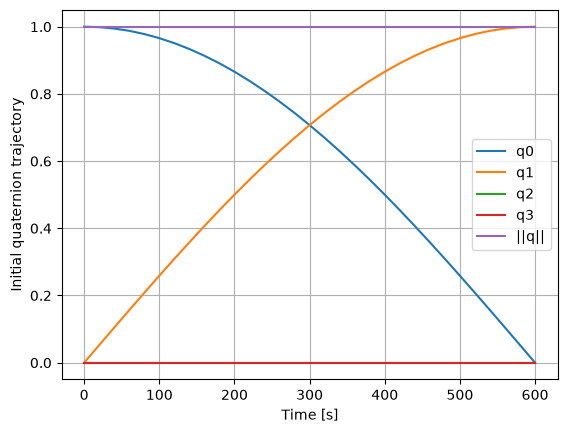

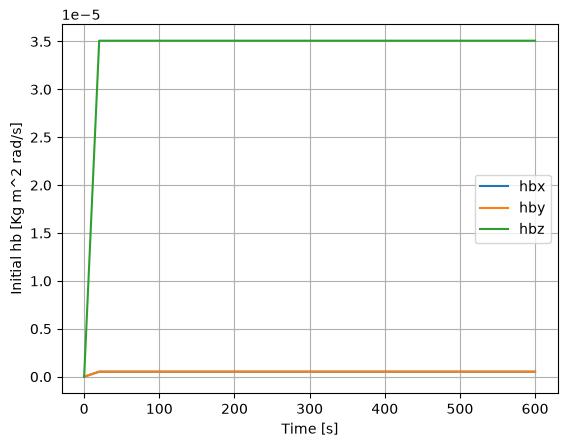

In [161]:
# Plot (scaled initial trajectories)

hu_value=np.copy(ohu_init)
hx_value=np.copy(ohx_init)

plt.figure(1)
plt.plot(np.linspace(0, tf_init, T+1), hx_value[0,:], label='q0')
plt.plot(np.linspace(0, tf_init, T+1), hx_value[1,:], label='q1')
plt.plot(np.linspace(0, tf_init, T+1), hx_value[2,:], label='q2')
plt.plot(np.linspace(0, tf_init, T+1), hx_value[3,:], label='q3')
plt.plot(np.linspace(0, tf_init, T+1), np.linalg.norm(hx_value[0:4,:],axis=0), label='||q||')
plt.ylabel('Initial quaternion trajectory')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(2)
plt.plot(np.linspace(0, tf_init, T+1), hx_value[4,:], label='hbx')
plt.plot(np.linspace(0, tf_init, T+1), hx_value[5,:], label='hby')
plt.plot(np.linspace(0, tf_init, T+1), hx_value[6,:], label='hbz')
plt.ylabel('Initial hb [Kg m^2 rad/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

# CVXpy

CVXpy Optimization problem (DPP compliant for cvxpygen)

In [162]:
x = cp.Variable((states_size, T + 1), name='x')
u = cp.Variable((inputs_size, T), name='u')
p = cp.Variable((params_size, 1), name='p')   # TIME DILATION (scaled): hp = S_p*p + c_p
vc = cp.Variable((states_size, T), name='vc')
if non_convex_inequalities_size>0:
    vi = cp.Variable((non_convex_inequalities_size, T+1), name='vi')

A_discrete = cp.Parameter((states_size,states_size*T), name='A_discrete')
B_discrete = cp.Parameter((states_size,inputs_size*T), name='B_discrete')
F_discrete = cp.Parameter((states_size,params_size*T), name='F_discrete')
y_discrete = cp.Parameter((states_size,1*T), name='y_discrete')

if non_convex_inequalities_size>0:
    C_discrete = cp.Parameter((non_convex_inequalities_size,states_size*(T+1)), name='C_discrete')
    D_discrete = cp.Parameter((non_convex_inequalities_size,inputs_size*(T+1)), name='D_discrete')
    G_discrete = cp.Parameter((non_convex_inequalities_size,params_size*(T+1)), name='G_discrete')
    z_discrete = cp.Parameter((non_convex_inequalities_size,1*(T+1)), name='z_discrete')

tau = cp.Parameter(name='tau')
sqrt_tau = cp.Parameter(name='sqrt_tau')
sqrt_tau_xq_goal = cp.Parameter((states_size,1), name='sqrt_tau_xq_goal')

start_pos = cp.Parameter((states_size,1), name='start_pos')
end_pos = cp.Parameter((states_size,1), name='end_pos')

ox_cvxpy = cp.Parameter((states_size,T + 1), name='ox_cvxpy')
ou_cvxpy = cp.Parameter((inputs_size,T), name='ou_cvxpy')
op_cvxpy = cp.Parameter((params_size,1), name='op_cvxpy')

S_x_scaling = cp.Parameter((states_size,states_size), name='S_x_scaling')
S_u_scaling = cp.Parameter((inputs_size,inputs_size), name='S_u_scaling')
S_p_scaling = cp.Parameter((params_size,params_size), name='S_p_scaling')

c_x_scaling = cp.Parameter((states_size,1), name='c_x_scaling')
c_u_scaling = cp.Parameter((inputs_size,1), name='c_u_scaling')
c_p_scaling = cp.Parameter((params_size,1), name='c_p_scaling')

# alpha_p_S_p := alpha_p * S_p (a single parameter, so that the terminal cost on
# the final time stays DPP compliant: parameter @ variable)
alpha_p_S_p = cp.Parameter((1,params_size), name='alpha_p_S_p')

tf_min_cvxpy = cp.Parameter(name='tf_min_cvxpy')
tf_max_cvxpy = cp.Parameter(name='tf_max_cvxpy')

inv_JW_S_W_scaling = cp.Parameter((3,3), name='inv_JW_S_W_scaling')
inv_JW_c_W_scaling = cp.Parameter((3,1), name='inv_JW_c_W_scaling')

inv_Jb_S_b_scaling = cp.Parameter((3,3), name='inv_Jb_S_b_scaling')
inv_Jb_c_b_scaling = cp.Parameter((3,1), name='inv_Jb_c_b_scaling')

lamb = cp.Parameter(name='lamb')
tau_lamb = cp.Parameter(name='tau_lamb')
etta = cp.Parameter(name='etta')

omegab_max = cp.Parameter(name='omegab_max')

torqW_max = cp.Parameter(name='torqW_max')
speedW_max = cp.Parameter(name='speedW_max')
Fth_max = cp.Parameter(name='Fth_max')

constraints = [
    x[0:7, 0:1] == start_pos[0:7,0:1],
    x[0:7, T:T+1] == end_pos[0:7,0:1]
]

cost = 0

# Running cost in NORMALIZED time (tau = 1/T). As in the manuscript (quadrotor
# example, Eq. (125)), the time dilation is deliberately omitted from the
# running cost: p*||u||_1 would be bilinear, hence non convex / non DPP.
for k in range(0, T):
    cost += 10*cp.norm(tau*u[0:4, k:k+1],1)
    #cost += 0.1*cp.sum_squares(sqrt_tau*u[3:7,k:k+1])
#for k in range(0, T+1):
    #cost += 1*cp.sum_squares(sqrt_tau*x[0:7,k:k+1]-sqrt_tau_xq_goal)

for k in range(0, T):
    cost += cp.norm(tau_lamb*vc[0:states_size, k:k+1],1)

if non_convex_inequalities_size>0:
    for k in range(0, T+1):
        cost += cp.norm(tau_lamb*vi[0:non_convex_inequalities_size, k:k+1],1)

# Convex terminal cost on the final time: phi = alpha_p*(S_p*p + c_p)
# (the constant offset alpha_p*c_p is irrelevant for the argmin)
cost += cp.sum(alpha_p_S_p @ p)

# Discretized dilated dynamics: x_{k+1} = A_k x_k + B_k u_k + F_k p + y_k + vc_k
for k in range(0, T): # from 0 to T-1
    constraints += [x[0:states_size, k+1:k+2] == A_discrete[0:states_size,states_size*k:states_size*(k+1)] @ x[0:states_size, k:k+1] + B_discrete[0:states_size,inputs_size*k:inputs_size*(k+1)] @ u[0:inputs_size, k:k+1]+F_discrete[0:states_size,params_size*k:params_size*(k+1)] @ p[0:params_size, 0:1]+y_discrete[0:states_size, k:k+1]+vc[0:states_size, k:k+1]]

if non_convex_inequalities_size>0:
    for k in range(0, T): # from 0 to T-1
        constraints += [C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] @ x[0:states_size, k:k+1] + D_discrete[0:non_convex_inequalities_size,inputs_size*k:inputs_size*(k+1)] @ u[0:inputs_size, k:k+1]+G_discrete[0:non_convex_inequalities_size,params_size*k:params_size*(k+1)] @ p[0:params_size, 0:1]+z_discrete[0:non_convex_inequalities_size, k:k+1]<=vi[0:non_convex_inequalities_size, k:k+1]]
    constraints += [C_discrete[0:non_convex_inequalities_size,states_size*T:states_size*(T+1)] @ x[0:states_size, T:T+1] + D_discrete[0:non_convex_inequalities_size,inputs_size*T:inputs_size*(T+1)] @ u[0:inputs_size, T-1:T]+G_discrete[0:non_convex_inequalities_size,params_size*T:params_size*(T+1)] @ p[0:params_size, 0:1]+z_discrete[0:non_convex_inequalities_size, T:T+1]<=vi[0:non_convex_inequalities_size, T:T+1]]

# Trust region including the parameter vector (manuscript Eqs. (46) and (51g)):
# ||dx||_inf + ||du||_inf + ||dp||_inf <= etta
for k in range(0, T): # from 0 to T-1
    constraints += [cp.norm(x[0:states_size, k:k+1]-ox_cvxpy[0:states_size,k:k+1],'inf')+cp.norm(u[0:inputs_size, k:k+1]-ou_cvxpy[0:inputs_size,k:k+1],'inf')+cp.norm(p[0:params_size, 0:1]-op_cvxpy[0:params_size,0:1],'inf')<=etta]
constraints  += [cp.norm(x[0:states_size, T:T+1]-ox_cvxpy[0:states_size,T:T+1],'inf')+cp.norm(u[0:inputs_size, T-1:T]-ou_cvxpy[0:inputs_size,T-1:T],'inf')+cp.norm(p[0:params_size, 0:1]-op_cvxpy[0:params_size,0:1],'inf')<=etta]

# Convex constraints
for k in range(0, T+1): # from 0 to T
    constraints += [cp.norm(inv_Jb_S_b_scaling@x[4:7,k:k+1]+inv_Jb_c_b_scaling, 2)<=omegab_max]
    
for k in range(0, T): # from 0 to T-1

    for i in range(0, 4):
        constraints += [
            0 <= S_u_scaling[i:i+1, i:i+1] @ u[i:i+1, k:k+1] + c_u_scaling[i:i+1, 0:1],
            S_u_scaling[i:i+1, i:i+1] @ u[i:i+1, k:k+1] + c_u_scaling[i:i+1, 0:1] <= Fth_max
        ]
    
    constraints += [cp.sum(S_u_scaling[0:2,0:2]@u[0:2,k:k+1]+c_u_scaling[0:2,0:1])<=Fth_max]
    constraints += [cp.sum(S_u_scaling[2:4,2:4]@u[2:4,k:k+1]+c_u_scaling[2:4,0:1])<=Fth_max]

# Free final time bounds (manuscript Eqs. (110) and (156)): tf_min <= p <= tf_max
constraints += [S_p_scaling@p[0:params_size,0:1]+c_p_scaling >= tf_min_cvxpy]
constraints += [S_p_scaling@p[0:params_size,0:1]+c_p_scaling <= tf_max_cvxpy]

objective = cp.Minimize(cost)
problem = cp.Problem(objective, constraints)

COMPULSORY: The problem needs to be DPP compliant for CVXpygen

In [163]:
print("Is DPP? ", problem.is_dcp(dpp=True))

Is DPP?  True


In [164]:
aux_A_discrete = np.zeros((states_size,states_size*T))
aux_B_discrete = np.zeros((states_size,inputs_size*T))
aux_F_discrete = np.zeros((states_size,params_size*T))
aux_y_discrete = np.zeros((states_size,1*T))

aux_C_discrete = np.zeros((non_convex_inequalities_size,states_size*(T+1)))
aux_D_discrete = np.zeros((non_convex_inequalities_size,inputs_size*(T+1)))
aux_G_discrete = np.zeros((non_convex_inequalities_size,params_size*(T+1)))
aux_z_discrete = np.zeros((non_convex_inequalities_size,1*(T+1)))

In [165]:
def SCVx_scaling_x(x_no_scaled,inv_S_x_scaling_double,c_x_scaling_double):
    x_scaled = inv_S_x_scaling_double@(x_no_scaled-c_x_scaling_double)
    return x_scaled
    
def SCVx_scaling_u(u_no_scaled,inv_S_u_scaling_double,c_u_scaling_double):
    u_scaled = inv_S_u_scaling_double@(u_no_scaled-c_u_scaling_double)
    return u_scaled

def SCVx_scaling_p(p_no_scaled,inv_S_p_scaling_double,c_p_scaling_double):
    p_scaled = inv_S_p_scaling_double@(p_no_scaled-c_p_scaling_double)
    return p_scaled

def SCVx_inv_scaling_x(x_scaled,S_x_scaling_double,c_x_scaling_double):
    x_inv_scaling = S_x_scaling_double@x_scaled+c_x_scaling_double
    return x_inv_scaling
    
def SCVx_inv_scaling_u(u_scaled,S_u_scaling_double,c_u_scaling_double):
    u_inv_scaling = S_u_scaling_double@u_scaled+c_u_scaling_double
    return u_inv_scaling

def SCVx_inv_scaling_p(p_scaled,S_p_scaling_double,c_p_scaling_double):
    p_inv_scaling = S_p_scaling_double@p_scaled+c_p_scaling_double
    return p_inv_scaling


def A_no_discrete_scaled_SCVx(A_no_discrete_no_scaled, inv_S_x_scaling_double,S_x_scaling_double):

    A_numeric = inv_S_x_scaling_double@A_no_discrete_no_scaled@S_x_scaling_double

    return A_numeric

def B_no_discrete_scaled_SCVx(B_no_discrete_no_scaled, inv_S_x_scaling_double, S_u_scaling_double):

    B_numeric = inv_S_x_scaling_double@B_no_discrete_no_scaled@S_u_scaling_double

    return B_numeric

def F_no_discrete_scaled_SCVx(F_no_discrete_no_scaled, inv_S_x_scaling_double, S_p_scaling_double):

    # F = S_x^-1 * hF * S_p   (time dilation Jacobian, scaled)
    F_numeric = inv_S_x_scaling_double@F_no_discrete_no_scaled@S_p_scaling_double

    return F_numeric

def y_no_discrete_scaled_SCVx(A_no_discrete_no_scaled,
                              B_no_discrete_no_scaled,
                              F_no_discrete_no_scaled,
                              y_no_discrete_no_scaled,
                              inv_S_x_scaling_double, c_x_scaling_double, c_u_scaling_double, c_p_scaling_double):

    y_numeric = inv_S_x_scaling_double@A_no_discrete_no_scaled@c_x_scaling_double
    y_numeric = y_numeric+inv_S_x_scaling_double@B_no_discrete_no_scaled@c_u_scaling_double
    y_numeric = y_numeric+inv_S_x_scaling_double@F_no_discrete_no_scaled@c_p_scaling_double
    y_numeric = y_numeric+inv_S_x_scaling_double@y_no_discrete_no_scaled

    return y_numeric
    
def A_B_F_y_discrete_scaled(ohx, ohu, ohp, t0, dynamic_parameters_double, tau_double,
                            S_x_scaling_double, inv_S_x_scaling_double, c_x_scaling_double,
                            S_u_scaling_double, inv_S_u_scaling_double, c_u_scaling_double,
                            S_p_scaling_double, inv_S_p_scaling_double, c_p_scaling_double, size_N):
    """
    ZOH discretization of the dilated LTV system (normalized time t in [0,1]):

        xdot = A(t)x + B(t)u + F(t)p + y(t)

        x_{k+1} = A_k x_k + B_k u_k + F_k p + y_k

        A_k = Phi(t_{k+1},t_k)
        B_k = Phi(t_{k+1},t_k) * int Phi^-1(xi,t_k) B(xi) dxi
        F_k = Phi(t_{k+1},t_k) * int Phi^-1(xi,t_k) F(xi) dxi
        y_k = Phi(t_{k+1},t_k) * int Phi^-1(xi,t_k) y(xi) dxi

    integrated with RK4 through:
        dPhi/dt = A Phi,  dG/dt = A G + B,  dH/dt = A H + F,  dz/dt = A z + y
    """

    n = len(ohx)
    m = len(ohu)
    d = len(ohp)

    Phi = np.eye(n)
    G   = np.zeros((n, m))
    H   = np.zeros((n, d))
    z   = np.zeros((n, 1))

    dt = tau_double / (size_N - 1)
    t  = t0

    def A_B_F_y_scaled_at(t_eval):

        A_no = A_no_discrete_no_scaled_SCVx(ohx, ohu, ohp, t_eval, dynamic_parameters_double)
        B_no = B_no_discrete_no_scaled_SCVx(ohx, ohu, ohp, t_eval, dynamic_parameters_double)
        F_no = F_no_discrete_no_scaled_SCVx(ohx, ohu, ohp, t_eval, dynamic_parameters_double)
        y_no = y_no_discrete_no_scaled_SCVx(ohx, ohu, ohp, t_eval, dynamic_parameters_double)

        A_s = A_no_discrete_scaled_SCVx(A_no, inv_S_x_scaling_double, S_x_scaling_double)
        B_s = B_no_discrete_scaled_SCVx(B_no, inv_S_x_scaling_double, S_u_scaling_double)
        F_s = F_no_discrete_scaled_SCVx(F_no, inv_S_x_scaling_double, S_p_scaling_double)
        y_s = y_no_discrete_scaled_SCVx(A_no, B_no, F_no, y_no,
                                        inv_S_x_scaling_double,
                                        c_x_scaling_double,
                                        c_u_scaling_double,
                                        c_p_scaling_double)
        return A_s, B_s, F_s, y_s

    for i in range(size_N - 1):

        # ===== k1 =====
        A1, B1, F1, y1 = A_B_F_y_scaled_at(t)

        k1_Phi = A1 @ Phi
        k1_G   = A1 @ G + B1
        k1_H   = A1 @ H + F1
        k1_z   = A1 @ z + y1

        # ===== k2 =====
        t2 = t + 0.5*dt
        Phi2 = Phi + 0.5*dt*k1_Phi
        G2   = G   + 0.5*dt*k1_G
        H2   = H   + 0.5*dt*k1_H
        z2   = z   + 0.5*dt*k1_z

        A2, B2, F2, y2 = A_B_F_y_scaled_at(t2)

        k2_Phi = A2 @ Phi2
        k2_G   = A2 @ G2 + B2
        k2_H   = A2 @ H2 + F2
        k2_z   = A2 @ z2 + y2

        # ===== k3 =====
        Phi3 = Phi + 0.5*dt*k2_Phi
        G3   = G   + 0.5*dt*k2_G
        H3   = H   + 0.5*dt*k2_H
        z3   = z   + 0.5*dt*k2_z

        A3, B3, F3, y3 = A_B_F_y_scaled_at(t2)

        k3_Phi = A3 @ Phi3
        k3_G   = A3 @ G3 + B3
        k3_H   = A3 @ H3 + F3
        k3_z   = A3 @ z3 + y3

        # ===== k4 =====
        t4 = t + dt
        Phi4 = Phi + dt*k3_Phi
        G4   = G   + dt*k3_G
        H4   = H   + dt*k3_H
        z4   = z   + dt*k3_z

        A4, B4, F4, y4 = A_B_F_y_scaled_at(t4)

        k4_Phi = A4 @ Phi4
        k4_G   = A4 @ G4 + B4
        k4_H   = A4 @ H4 + F4
        k4_z   = A4 @ z4 + y4

        # ===== Update =====
        Phi += (dt/6)*(k1_Phi + 2*k2_Phi + 2*k3_Phi + k4_Phi)
        G   += (dt/6)*(k1_G   + 2*k2_G   + 2*k3_G   + k4_G)
        H   += (dt/6)*(k1_H   + 2*k2_H   + 2*k3_H   + k4_H)
        z   += (dt/6)*(k1_z   + 2*k2_z   + 2*k3_z   + k4_z)

        t += dt

    return Phi, G, H, z

def C_no_discrete_scaled_SCVx(C_no_discrete_no_scaled, S_x_scaling_double):

    C_numeric = C_no_discrete_no_scaled@S_x_scaling_double

    return C_numeric

def D_no_discrete_scaled_SCVx(D_no_discrete_no_scaled, S_u_scaling_double):

    D_numeric = D_no_discrete_no_scaled@S_u_scaling_double

    return D_numeric

def G_no_discrete_scaled_SCVx(G_no_discrete_no_scaled, S_p_scaling_double):

    G_numeric = G_no_discrete_no_scaled@S_p_scaling_double

    return G_numeric

def z_no_discrete_scaled_SCVx(C_no_discrete_no_scaled,
                              D_no_discrete_no_scaled,
                              G_no_discrete_no_scaled,
                              z_no_discrete_no_scaled,
                              c_x_scaling_double, c_u_scaling_double, c_p_scaling_double):

    z_numeric = C_no_discrete_no_scaled@c_x_scaling_double
    z_numeric = z_numeric+D_no_discrete_no_scaled@c_u_scaling_double
    z_numeric = z_numeric+G_no_discrete_no_scaled@c_p_scaling_double
    z_numeric = z_numeric+z_no_discrete_no_scaled

    return z_numeric

def C_D_G_z_discrete_scaled(ohx, ohu, ohp, t0, dynamic_parameters,
                            S_x_scaling_double, c_x_scaling_double,
                            S_u_scaling_double, c_u_scaling_double,
                            S_p_scaling_double, c_p_scaling_double):
    

    C_no_discrete_no_scaled = C_no_discrete_no_scaled_SCVx(ohx, ohu, ohp, t0, dynamic_parameters)
    C_no_discrete_scaled = C_no_discrete_scaled_SCVx(C_no_discrete_no_scaled, S_x_scaling_double)

    
    D_no_discrete_no_scaled = D_no_discrete_no_scaled_SCVx(ohx, ohu, ohp, t0, dynamic_parameters)
    D_no_discrete_scaled = D_no_discrete_scaled_SCVx(D_no_discrete_no_scaled, S_u_scaling_double)

    G_no_discrete_no_scaled = G_no_discrete_no_scaled_SCVx(ohx, ohu, ohp, t0, dynamic_parameters)
    G_no_discrete_scaled = G_no_discrete_scaled_SCVx(G_no_discrete_no_scaled, S_p_scaling_double)

    z_no_discrete_no_scaled = z_no_discrete_no_scaled_SCVx(ohx, ohu, ohp, t0, dynamic_parameters)
    z_no_discrete_scaled = z_no_discrete_scaled_SCVx(C_no_discrete_no_scaled,
                                                     D_no_discrete_no_scaled,
                                                     G_no_discrete_no_scaled,
                                                     z_no_discrete_no_scaled,
                                                     c_x_scaling_double, c_u_scaling_double, c_p_scaling_double)
    
    #Discretization no needed, bypass
    return C_no_discrete_scaled, D_no_discrete_scaled, G_no_discrete_scaled, z_no_discrete_scaled

def f_rk4_step(xk, uk, pk, t, dt, dynamic_parameters,
               S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double,
               S_p_scaling_double,c_p_scaling_double):
    
    # dt is a NORMALIZED step: f_SCVx already contains the dilation factor p
    xk_no_scaled = SCVx_inv_scaling_x(xk,S_x_scaling_double,c_x_scaling_double)
    uk_no_scaled = SCVx_inv_scaling_u(uk,S_u_scaling_double,c_u_scaling_double)
    pk_no_scaled = SCVx_inv_scaling_p(pk,S_p_scaling_double,c_p_scaling_double)
    k1 = f_SCVx(xk_no_scaled, uk_no_scaled, pk_no_scaled, t, dynamic_parameters)
    k2 = f_SCVx(xk_no_scaled + 0.5 * dt * k1, uk_no_scaled, pk_no_scaled, t + 0.5*dt, dynamic_parameters)
    k3 = f_SCVx(xk_no_scaled + 0.5 * dt * k2, uk_no_scaled, pk_no_scaled, t + 0.5*dt, dynamic_parameters)
    k4 = f_SCVx(xk_no_scaled + dt * k3, uk_no_scaled, pk_no_scaled, t + dt, dynamic_parameters)
    return xk_no_scaled + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

def f_Euler_step(xk, uk, pk, t, dt, dynamic_parameters,
                 S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double,
                 S_p_scaling_double,c_p_scaling_double):

    xk_no_scaled = SCVx_inv_scaling_x(xk,S_x_scaling_double,c_x_scaling_double)
    uk_no_scaled = SCVx_inv_scaling_u(uk,S_u_scaling_double,c_u_scaling_double)
    pk_no_scaled = SCVx_inv_scaling_p(pk,S_p_scaling_double,c_p_scaling_double)

    return xk_no_scaled + dt * f_SCVx(xk_no_scaled, uk_no_scaled, pk_no_scaled, t, dynamic_parameters)


Modify the SCVx cost function according to user requirements:

In [166]:
def J_SCVx(x,u,p,T,tau_double, dynamic_parameters, xq_goal_double,
           S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double,
           S_p_scaling_double,c_p_scaling_double):

    # Non linear augmented cost (manuscript Eq. (60)). Everything is evaluated in
    # NORMALIZED time: tau_double = 1/T and the flow map propagates the dilated
    # dynamics p*f(x,u).
    
    cost = 0
    for k in range(0, T): # from 0 to T-1
        cost += 10*tau_double*np.linalg.norm(u[0:4,k:k+1], ord=1)

    #for k in range(0, T+1):
    #    cost += 1*tau_double*np.linalg.norm(x[0:7,k:k+1]-xq_goal_double, ord=2)**2

    for k in range(0, T): # from 0 to T-1

        flow_map = f_rk4_step(x[0:, k:k+1], u[:, k:k+1], p[:, 0:1], k*tau_double, tau_double, dynamic_parameters,
        S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double,
        S_p_scaling_double,c_p_scaling_double)

        SCVx_defect = SCVx_inv_scaling_x(x[:, k+1:k+2],S_x_scaling_double,c_x_scaling_double)-flow_map

        cost += tau_double*np.linalg.norm(lamb_double*SCVx_defect, ord=1)

    for k in range(0, T+1): # from 0 to T
        x_no_scaled = SCVx_inv_scaling_x(x[:,k:k+1],S_x_scaling_double,c_x_scaling_double)
        p_no_scaled = SCVx_inv_scaling_p(p[:,0:1],S_p_scaling_double,c_p_scaling_double)
        if k == T:
            u_no_scaled = SCVx_inv_scaling_u(u[:,T-1:T],S_u_scaling_double,c_u_scaling_double)
        else:
            u_no_scaled = SCVx_inv_scaling_u(u[:,k:k+1],S_u_scaling_double,c_u_scaling_double)
        if non_convex_inequalities_size>0:    
            g_double = g_SCVx(x_no_scaled, u_no_scaled, p_no_scaled, k*tau_double, dynamic_parameters_double)

            for i in range(0,np.size(g_double)):
                cost += tau_double*np.abs(lamb_double*(np.max([g_double[i,0],0])))

    # Terminal cost on the final time (same term as in the convex subproblem)
    cost += alpha_p_double*(S_p_scaling_double@p[:,0:1]+c_p_scaling_double)[0,0]

    return cost

# SCVx

In [167]:
ox = np.zeros((states_size,T+1))
ou = np.zeros((inputs_size,T))
op = np.zeros((params_size,1))
etta_double = np.copy(etta_double_init)

inv_S_x_scaling_double = np.linalg.inv(S_x_scaling_double)
inv_S_u_scaling_double = np.linalg.inv(S_u_scaling_double)
inv_S_p_scaling_double = np.linalg.inv(S_p_scaling_double)

ohx = np.copy(ohx_init) 
ohu = np.copy(ohu_init)
ohp = np.copy(ohp_init)

for t in range(0, T + 1):
    ox[0:states_size,t:t+1] = SCVx_scaling_x(ohx[0:states_size,t:t+1],inv_S_x_scaling_double,c_x_scaling_double)

for t in range(0, T):
    ou[0:inputs_size,t:t+1] = SCVx_scaling_u(ohu[0:inputs_size,t:t+1],inv_S_u_scaling_double,c_u_scaling_double)

op[0:params_size,0:1] = SCVx_scaling_p(ohp[0:params_size,0:1],inv_S_p_scaling_double,c_p_scaling_double)

ox_cvxpy.value=ox #trajectory initialization (already scaled)
ou_cvxpy.value=ou #trajectory initialization (already scaled)
op_cvxpy.value=np.copy(op) #time dilation initialization (already scaled)

tau.value = tau_double
sqrt_tau.value = (tau_double)**0.5

lamb.value = lamb_double

tau_lamb.value = tau_double*lamb_double
etta.value = etta_double

S_x_scaling.value = S_x_scaling_double
S_u_scaling.value = S_u_scaling_double
S_p_scaling.value = S_p_scaling_double

c_x_scaling.value = c_x_scaling_double
c_u_scaling.value = c_u_scaling_double
c_p_scaling.value = c_p_scaling_double

alpha_p_S_p.value = alpha_p_double*S_p_scaling_double

tf_min_cvxpy.value = tf_min
tf_max_cvxpy.value = tf_max

omegab_max.value = omegab_max_double
Fth_max.value = Fth_max_double

start_pos.value = SCVx_scaling_x(start_pos_double,inv_S_x_scaling_double,c_x_scaling_double)
end_pos_aux = SCVx_scaling_x(end_pos_double,inv_S_x_scaling_double,c_x_scaling_double)
end_pos.value = np.copy(end_pos_aux)

sqrt_tau_xq_goal_double = (tau_double)**0.5*end_pos_aux[0:7,0:1]
xq_goal_double = np.copy(end_pos_aux[0:7,0:1])
sqrt_tau_xq_goal.value = np.copy(sqrt_tau_xq_goal_double)

inv_Jb_S_b_scaling.value = np.linalg.inv(Jsat_double)@S_x_scaling_double[4:7,4:7]
inv_Jb_c_b_scaling.value = np.linalg.inv(Jsat_double)@c_x_scaling_double[4:7,0:1]

t0 = time.time()

i=1
no_first_iterations = False
rho_i = "None"

for COGU_iter in range(COGU_max_iter):


    for t in range(0, T + 1):
        ohx[0:states_size,t:t+1] = SCVx_inv_scaling_x(ox[0:states_size,t:t+1],S_x_scaling_double,c_x_scaling_double)

    for t in range(0, T):
        ohu[0:inputs_size,t:t+1] = SCVx_inv_scaling_u(ou[0:inputs_size,t:t+1],S_u_scaling_double,c_u_scaling_double)

    ohp[0:params_size,0:1] = SCVx_inv_scaling_p(op[0:params_size,0:1],S_p_scaling_double,c_p_scaling_double)

    t0aux = time.time()
    
    for k in range(0, T):
        aux_aux_A_discrete, aux_aux_B_discrete, aux_aux_F_discrete, aux_aux_y_discrete = A_B_F_y_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,k:k+1], ohp[0:params_size,0:1], k*tau_double, dynamic_parameters_double, tau_double,
                          S_x_scaling_double, inv_S_x_scaling_double, c_x_scaling_double,
                          S_u_scaling_double, inv_S_u_scaling_double, c_u_scaling_double,
                          S_p_scaling_double, inv_S_p_scaling_double, c_p_scaling_double, size_N)

        aux_A_discrete[0:states_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_A_discrete)
        
        aux_B_discrete[0:states_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_B_discrete)

        aux_F_discrete[0:states_size,params_size*k:params_size*(k+1)] = np.copy(aux_aux_F_discrete)
        
        aux_y_discrete[0:states_size,k:k+1] = np.copy(aux_aux_y_discrete)

    if non_convex_inequalities_size>0:
      for k in range(0, T+1):
          aux_aux_C_discrete, aux_aux_D_discrete, aux_aux_G_discrete, aux_aux_z_discrete = C_D_G_z_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,min(k,T-1):min(k,T-1)+1], ohp[0:params_size,0:1], k*tau_double, dynamic_parameters_double,
                  S_x_scaling_double, c_x_scaling_double,
                  S_u_scaling_double, c_u_scaling_double,
                  S_p_scaling_double, c_p_scaling_double)
          
          aux_C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_C_discrete)
        
          aux_D_discrete[0:non_convex_inequalities_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_D_discrete)

          aux_G_discrete[0:non_convex_inequalities_size,params_size*k:params_size*(k+1)] = np.copy(aux_aux_G_discrete)
          
          aux_z_discrete[0:non_convex_inequalities_size,k:k+1] = np.copy(aux_aux_z_discrete)

    t1aux = time.time()
    print("Discretization time [ms]: ",(t1aux-t0aux)*1000)

    A_discrete.value = np.copy(aux_A_discrete)
    B_discrete.value = np.copy(aux_B_discrete)
    F_discrete.value = np.copy(aux_F_discrete)
    y_discrete.value = np.copy(aux_y_discrete)
    
    if non_convex_inequalities_size>0:
      C_discrete.value = np.copy(aux_C_discrete)
      D_discrete.value = np.copy(aux_D_discrete)
      G_discrete.value = np.copy(aux_G_discrete)
      z_discrete.value = np.copy(aux_z_discrete)

    t0aux = time.time()
    val=problem.solve(solver='ECOS',ignore_dpp=False,verbose=False,max_iters=200) #IF YOU USE CVXPYGEN: ignore_dpp=False
    t1aux = time.time()

    print("Solver time [ms]: ",(t1aux-t0aux)*1000)

    vc_opt=np.copy(vc.value)
    if non_convex_inequalities_size>0:
      vi_opt=np.copy(vi.value)
    x_opt=np.copy(x.value)
    u_opt=np.copy(u.value)
    p_opt=np.copy(p.value)

    L_SCVx_opt=val

    J_SCVx_opt=J_SCVx(x_opt,u_opt,p_opt,T,tau_double, dynamic_parameters_double, xq_goal_double,
                      S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double,
                      S_p_scaling_double,c_p_scaling_double)
    oJ_SCVx=J_SCVx(ox,ou,op,T,tau_double, dynamic_parameters_double, xq_goal_double,
                      S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double,
                      S_p_scaling_double,c_p_scaling_double)
    
    print("Iteration number: ",i," Etta: ",etta.value, " Rho: ",rho_i, " tf [s]: ",(S_p_scaling_double@p_opt+c_p_scaling_double)[0,0])
    print("L_SCVx_opt: "+str(val)+" J_SCVx_opt: "+str(J_SCVx_opt)+" oJ_SCVx: "+str(oJ_SCVx)+" Norm_x_diff: "+str(np.max(np.linalg.norm((x_opt-ox), ord=2,axis=0))),"\n")
    
    
    Delta_J_SCVx=oJ_SCVx-J_SCVx_opt
    #Delta_L_SCVx=J_SCVx_opt-L_SCVx_opt
    Delta_L_SCVx=oJ_SCVx-L_SCVx_opt

    """
    ox=np.copy(x_opt)
    ou=np.copy(u_opt)
    """
    
    if (Delta_L_SCVx<e_tol*np.abs(oJ_SCVx) or (np.max(np.linalg.norm((x_opt-ox), ord=1,axis=0))<epsilon_stop_norm and np.linalg.norm((p_opt-op), ord=1)<epsilon_stop_norm)) and no_first_iterations:
      x_global=np.copy(ox)
      u_global=np.copy(ou)
      p_global=np.copy(op)
      tf_global=(S_p_scaling_double@p_global+c_p_scaling_double)[0,0]
      print("Maximum iterations unreached! :)  tf = "+str(tf_global)+" s")
      break;
    else:
      rho_i=Delta_J_SCVx/Delta_L_SCVx
      if rho_i<rho0:
        etta.value=max([etta0,etta.value/beta_sh])
        ox=np.copy(ox)
        ou=np.copy(ou)
        op=np.copy(op)
      if rho_i>=rho0 and rho_i<rho1:
        etta.value=max([etta0,etta.value/beta_sh])
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)
        op=np.copy(p_opt)
      if rho_i>=rho1 and rho_i<rho2:
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)
        op=np.copy(p_opt)
      if rho_i>=rho2:
        etta.value=min([etta1,beta_gr*etta.value])
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)
        op=np.copy(p_opt)

    ox_cvxpy.value=np.copy(ox)
    ou_cvxpy.value=np.copy(ou)
    op_cvxpy.value=np.copy(op)

    if i==3:
        no_first_iterations = True
    i=i+1
    
t1 = time.time()
print('\nCVXPY\nSolve time: %.3f ms' % (1000 * (t1 - t0)))

Discretization time [ms]:  221.4946746826172
Solver time [ms]:  1395.4088687896729
Iteration number:  1  Etta:  1.0  Rho:  None  tf [s]:  298.6338527420609
L_SCVx_opt: 34.92721009409077 J_SCVx_opt: 302.10558747746586 oJ_SCVx: 707.6714755699156 Norm_x_diff: 0.2165271416583258 

Discretization time [ms]:  214.05339241027832
Solver time [ms]:  19.983768463134766
Iteration number:  2  Etta:  1.0  Rho:  0.6028529842697319  tf [s]:  585.6905366287506
L_SCVx_opt: 49.35210759859526 J_SCVx_opt: 251.42582349052725 oJ_SCVx: 302.10558747746586 Norm_x_diff: 0.16938884470218052 

Discretization time [ms]:  217.026948928833
Solver time [ms]:  21.001815795898438
Iteration number:  3  Etta:  1.0  Rho:  0.20051064781076938  tf [s]:  410.751314985725
L_SCVx_opt: 34.022827721599356 J_SCVx_opt: 155.0714546937777 oJ_SCVx: 251.42582349052725 Norm_x_diff: 0.24618251853772483 

Discretization time [ms]:  218.07551383972168
Solver time [ms]:  17.986059188842773
Iteration number:  4  Etta:  1.0  Rho:  0.44320626

In [168]:
print("||v_c||_1 (non linear model accuracy) = ",np.linalg.norm((vc.value[:, :]), ord=1))
if non_convex_inequalities_size>0:
    print("||v_i||_i (non convex constraints accuracy) = ",np.linalg.norm((vi.value[:, :]), ord=1))

||v_c||_1 (non linear model accuracy) =  0.00017762670926170995


Optimal final time tf [s]:  443.9383032554332


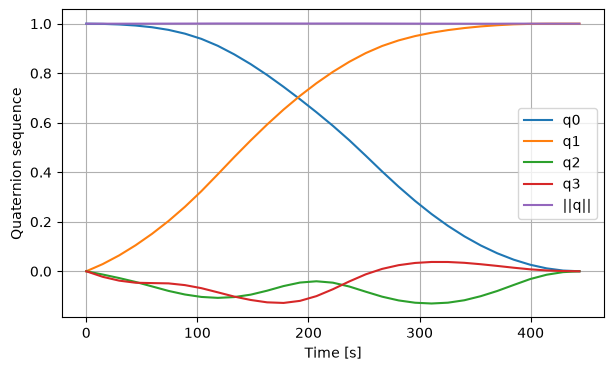

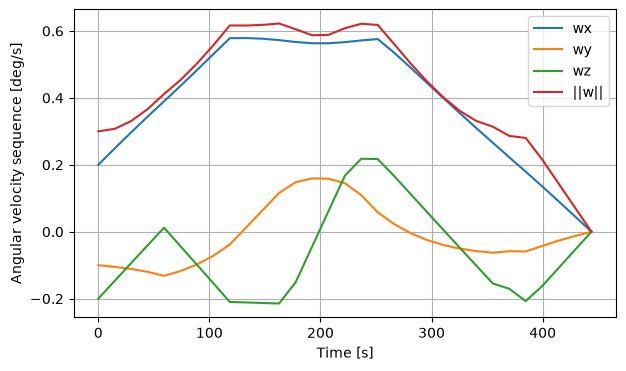

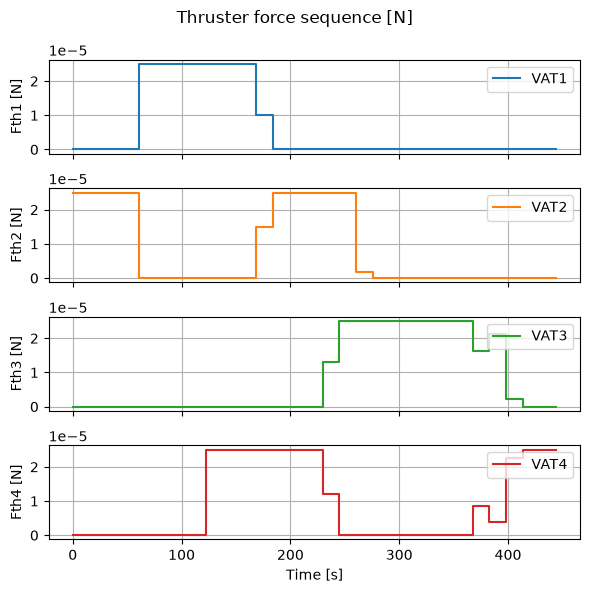

In [169]:
# Plot (scaled initial trajectories)
def global_inv_scaling(x,S,c,T):
    for i in range(0,T,1):
        x[:,i:i+1]=S@x[:,i:i+1]+c
    return x

#Uncomment if there is no optimal solution (or keyboard interruption)

x_value=global_inv_scaling(np.copy(ox),S_x_scaling_double,c_x_scaling_double,T+1)
u_value=global_inv_scaling(np.copy(ou),S_u_scaling_double,c_u_scaling_double,T)

# ---------------------------------------------------------------------------
# Converged final time (time dilation): |t| = p*t.
# 'tf' and 'tau_double_abs' are (re)defined here in ABSOLUTE time so that every
# open/closed-loop simulation cell below keeps working exactly as before.
# ---------------------------------------------------------------------------
tf = (S_p_scaling_double@op+c_p_scaling_double)[0,0]
tau_double_abs = tf/T
print("Optimal final time tf [s]: ",tf)

for i in range(0,T+1):
    x_value[4:7,i:i+1] = np.linalg.inv(Jsat_double)@x_value[4:7,i:i+1]

#x_value=global_inv_scaling(np.copy(x_global),S_x_scaling_double,c_x_scaling_double,T+1)
#u_value=global_inv_scaling(np.copy(u_global),S_u_scaling_double,c_u_scaling_double,T)

plt.figure(1, figsize=(7, 4))
plt.plot(np.linspace(0, tf, T+1), x_value[0,:], label='q0')
plt.plot(np.linspace(0, tf, T+1), x_value[1,:], label='q1')
plt.plot(np.linspace(0, tf, T+1), x_value[2,:], label='q2')
plt.plot(np.linspace(0, tf, T+1), x_value[3,:], label='q3')
plt.plot(np.linspace(0, tf, T+1), np.linalg.norm(x_value[0:4,:],axis=0), label='||q||')
plt.ylabel('Quaternion sequence')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(2, figsize=(7, 4))
plt.plot(np.linspace(0, tf, T+1), x_value[4,:]*180/np.pi, label='wx')
plt.plot(np.linspace(0, tf, T+1), x_value[5,:]*180/np.pi, label='wy')
plt.plot(np.linspace(0, tf, T+1), x_value[6,:]*180/np.pi, label='wz')
plt.plot(np.linspace(0, tf, T+1), np.linalg.norm(x_value[4:7,:],axis=0)*180/np.pi, label='||w||')

plt.ylabel('Angular velocity sequence [deg/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(6, 6))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for i in range(4):
    axs[i].step(np.linspace(0, tf, T), u_value[i, :], where='post',
                color=colors[i], label=f'VAT{i+1}')
    axs[i].set_ylabel(f'Fth{i+1} [N]')
    axs[i].grid(True)
    axs[i].legend(loc='upper right')
    axs[i].tick_params(labelsize=10)

axs[-1].set_xlabel('Time [s]')
fig.suptitle('Thruster force sequence [N]')
fig.tight_layout()
plt.show()


# Open loop (VAT, COGU, ideal)

[warning] dt_state=0.1s does not divide dt_control=14.797943441847773s -> ZOH boundaries do not land exactly on integration steps


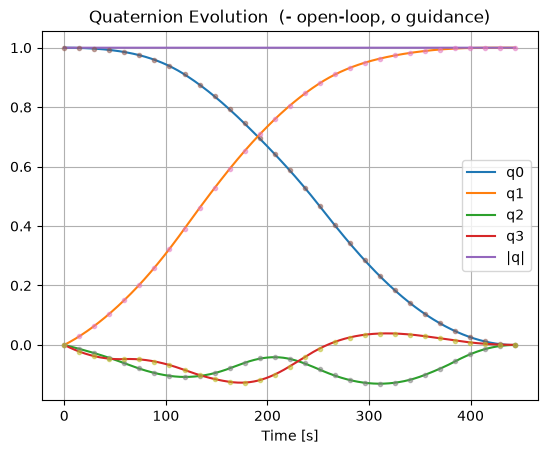

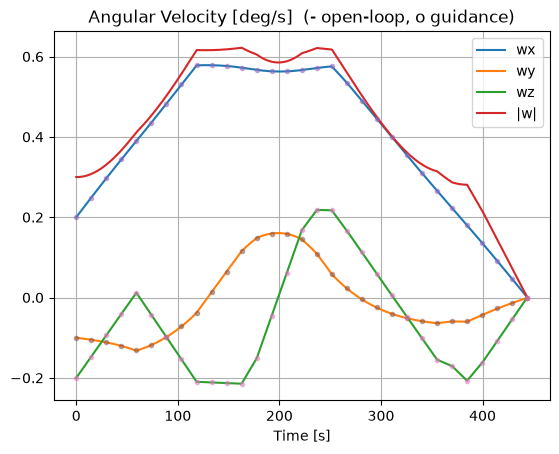

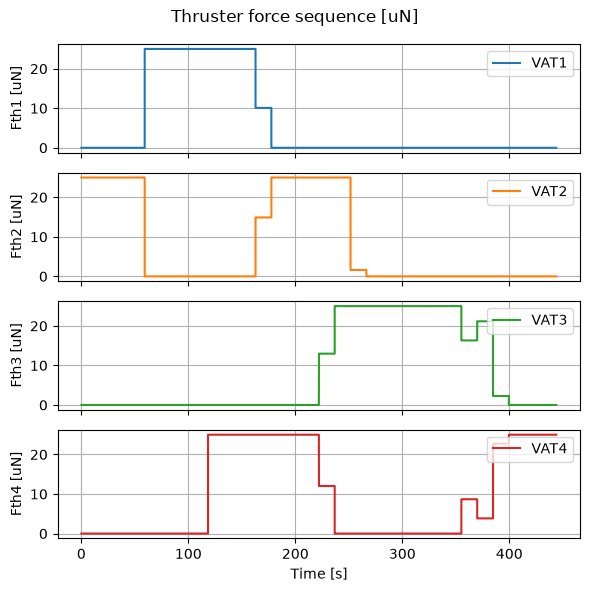

In [170]:
B = np.column_stack([
    np.cross(rth1_double[:, 0], fth1_double[:, 0]),
    np.cross(rth2_double[:, 0], fth2_double[:, 0]),
    np.cross(rth3_double[:, 0], fth3_double[:, 0]),
    np.cross(rth4_double[:, 0], fth4_double[:, 0]),
])
 
 
# =========================================
# Control interpolation
# =========================================
def u_interpol_zoh(t, u_value, dt_control):
    """Zero-order hold: the SCVx control is constant over each interval."""
    T_control = u_value.shape[1]
    index = int(np.floor(t / dt_control))
    index = min(index, T_control - 1)
    return u_value[:, index]

# =========================================
# Dynamics
# =========================================
def dynamics(t, x, u, params):
 
    q = x[0:4]
    w = x[4:7]
 
    I     = params["I"]
    I_inv = params["I_inv"]
    B     = params["B"]
 
    torque = B @ u                                   # M = sum_i u_i (rth_i x fth_i)
    w_dot  = I_inv @ (torque - np.cross(w, I @ w))   # Euler
 
    wx, wy, wz = w
    q0, q1, q2, q3 = q
 
    q_dot = 0.5 * np.array([
        -wx*q1 - wy*q2 - wz*q3,
         wx*q0 + wz*q2 - wy*q3,
         wy*q0 - wz*q1 + wx*q3,
         wz*q0 + wy*q1 - wx*q2
    ])
 
    return np.concatenate((q_dot, w_dot))
 
 
# =========================================
# RK4 Integrator
# =========================================
def rk4_step(f, t, x, u, dt, params):
 
    k1 = f(t,        x,             u, params)
    k2 = f(t + dt/2, x + dt/2 * k1, u, params)
    k3 = f(t + dt/2, x + dt/2 * k2, u, params)
    k4 = f(t + dt,   x + dt   * k3, u, params)
 
    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
 
 
# =========================================
# Simulation setup
# =========================================
I = Jsat_double.copy()
 
params = {
    "I":     I,
    "I_inv": np.linalg.inv(I),
    "B":     B,
}
 
# Initial state = guidance node 0.  x_value[4:7] is already omega [rad/s].
x = x_value[:, 0].copy()
 
dt_state   = 0.1                          # integration step [s]
dt_control = tau_double_abs                   # guidance step (ZOH) [s]
sim_time   = tf                           # guidance horizon = T*tau
N = int(round(sim_time / dt_state)) + 1
 
if abs(dt_control / dt_state - round(dt_control / dt_state)) > 1e-9:
    print(f"[warning] dt_state={dt_state}s does not divide dt_control={dt_control}s "
          f"-> ZOH boundaries do not land exactly on integration steps")
 
q_history = np.zeros((N, 4))
w_history = np.zeros((N, 3))
u_history = np.zeros((N, 4))
t_history = np.zeros(N)
 
t = 0.0
 
# =========================================
# Simulation loop  (open-loop: SCVx ZOH control)
# =========================================
for i in range(N):
 
    q_history[i] = x[0:4]
    w_history[i] = x[4:7]
    t_history[i] = t
 
    u_current = u_interpol_zoh(t, 1.0*u_value, dt_control)
    u_history[i] = u_current
 
    x = rk4_step(dynamics, t, x, u_current, dt_state, params)
    x[0:4] /= np.linalg.norm(x[0:4])      # renormalize q
    t += dt_state
 
 
# =========================================
# Plots
# =========================================
t_nodes = np.arange(T + 1) * tau_double_abs
 
plt.figure()
plt.plot(t_history, q_history)
plt.plot(t_history, np.linalg.norm(q_history, axis=1))
plt.plot(t_nodes, x_value[0:4, :].T, 'o', ms=3, alpha=0.5)
plt.legend(["q0","q1","q2","q3","|q|"])
plt.title("Quaternion Evolution  (- open-loop, o guidance)")
plt.xlabel("Time [s]"); plt.grid(); plt.show()
 
plt.figure()
plt.plot(t_history, w_history * 180/np.pi)
plt.plot(t_history, np.linalg.norm(w_history, axis=1) * 180/np.pi)
plt.plot(t_nodes, x_value[4:7, :].T * 180/np.pi, 'o', ms=3, alpha=0.5)
plt.legend(["wx","wy","wz","|w|"])
plt.title("Angular Velocity [deg/s]  (- open-loop, o guidance)")
plt.xlabel("Time [s]"); plt.grid(); plt.show()

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(6, 6))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for i in range(4):
    axs[i].step(t_history, u_history[:, i] * 1e6, where='post',
                color=colors[i], label=f'VAT{i+1}')
    axs[i].set_ylabel(f'Fth{i+1} [uN]')
    axs[i].grid(True)
    axs[i].legend(loc='upper right')
    axs[i].tick_params(labelsize=10)

axs[-1].set_xlabel('Time [s]')
fig.suptitle('Thruster force sequence [uN]')
fig.tight_layout()
plt.show()

# Open loop with disturbances (VAT, COGU)

Time dilation solution : tf = 443.94 s,  dt_control = 14.798 s
Torque authority per thruster [uN.m]: [1.903 1.903 1.903 1.903]
Momentum quantum per pulse   [uN.m.s]: 1.9033
Attainable pointing floor    [deg]   : 0.0169 per residual quantum-second
Max COGU pair duty = 1.00 (pulse_width = 1.00), spare authority ~ 35 %
Diagonal inertia error (%): [3.1 0.4 3.6]

--- A: open loop (COGU only) ---
  pair exclusivity           : True
  pulses per thruster        : [110 143 150 176]  (total 579)
  final pointing error       : 11.287 deg
  final rate error           : 0.0651 deg/s
  max deviation vs reference : 11.287 deg

--- B: + disturbance rejection ---
  pair exclusivity           : True
  pulses per thruster        : [110 143 162 164]  (total 579)
  final pointing error       : 9.629 deg
  final rate error           : 0.0430 deg/s
  max deviation vs reference : 9.629 deg

--- C: + terminal-optimal tracking ---
  pair exclusivity           : True
  pulses per thruster        : [110 143 156 

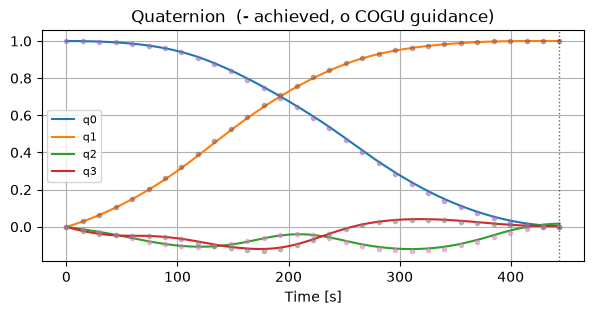

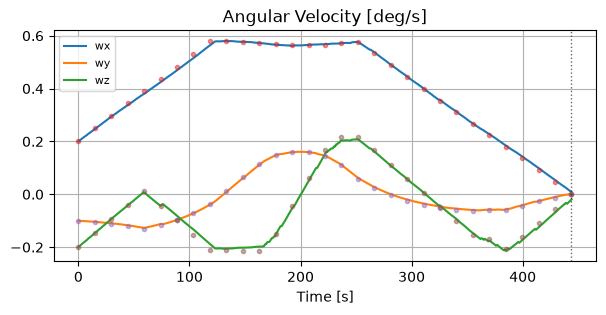

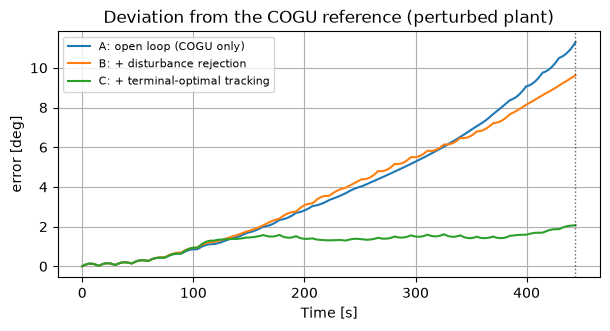

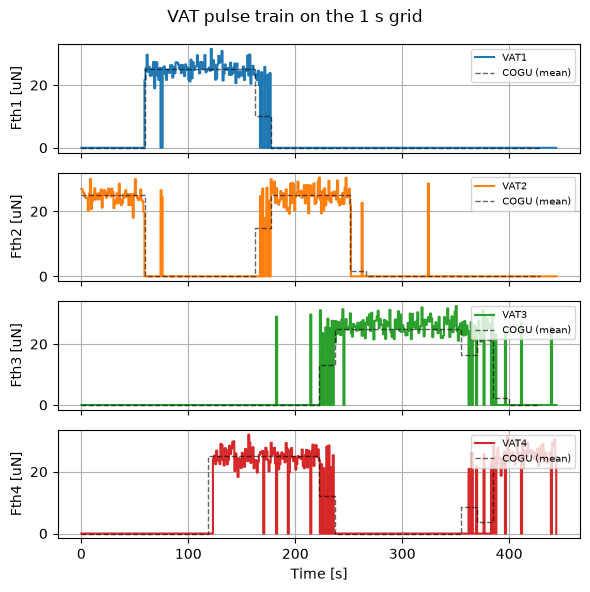

In [171]:
# ============================================================================
#  VAT ATTITUDE MANOEUVRE:  COGU feedforward + real-time disturbance rejection
#                           + terminal-optimal quantized tracking
#  Sigma-Delta scheduler on a 1 s pulse grid, pair-exclusive actuation
# ----------------------------------------------------------------------------
#  THE PROBLEM
#  -----------
#  With a 5% inertia error, NO purely feedforward scheme can deliver a good
#  final pointing: the inertia error is a MODEL error, invisible to any
#  scheduler that only propagates what it believes it is doing. In the tests it
#  alone produces tens of degrees over a large slew, swamping the disturbance.
#  So the strategy has to close the loop on the state -- and the EKF that
#  estimates the disturbance already provides it.
#
#  THREE MODES (control_mode)
#  --------------------------
#   "open_loop"        : COGU replayed as pulses. Baseline.
#   "ff_dist"          : + real-time disturbance rejection (feedforward only).
#                        Cancels tau_d, blind to inertia error and bias.
#   "terminal"         : + quantized tracking with TERMINAL-OPTIMAL gains.
#                        This is the recommended one.
#
#  WHY "terminal"
#  --------------
#  Attitude error is the double integral of torque error. For a double
#  integrator, the minimum-effort law that nulls BOTH the angle and the rate
#  error exactly at t_go = 0 is
#
#        a_corr = -(6/t_go^2) dtheta - (4/t_go) domega
#
#  i.e. a PD with time-varying gains that tighten as the manoeuvre ends. It
#  targets the FINAL pointing error directly instead of the instantaneous one,
#  and it spends the available pulses where they buy the most terminal accuracy.
#  Feeding tau_ff - tau_d_hat + J*a_corr through the Sigma-Delta quantizer keeps
#  the pair-exclusivity and 1 s grid constraints exactly.
#
#  The momentum accumulator is RESET from the measured state every slot, so the
#  quantizer never double-counts an error the feedback has already seen.
#
#  ACTUATION CONSTRAINT (respected in every mode)
#  ----------------------------------------------
#  One pulse per second, one thruster per antagonistic pair {VAT1,VAT2} and
#  {VAT3,VAT4}: 9 admissible actuations per slot. Their torques come in +/-
#  pairs and rank(B) = 3, so any direction is reachable ON AVERAGE.
#
#  <<< EKF HOOKS >>>  disturbance_estimate(t) and state_estimate(t, x)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

control_mode = "terminal"        # "open_loop" | "ff_dist" | "terminal"
compare_all  = True              # run the three modes and compare

# =========================================
# Thruster control matrix B
# =========================================
B = np.column_stack([
    np.cross(rth1_double[:, 0], fth1_double[:, 0]),
    np.cross(rth2_double[:, 0], fth2_double[:, 0]),
    np.cross(rth3_double[:, 0], fth3_double[:, 0]),
    np.cross(rth4_double[:, 0], fth4_double[:, 0]),
])

I_nominal = Jsat_double.copy()
I_nom_inv = np.linalg.inv(I_nominal)

# =========================================
# Guidance horizon coming from the time dilation
# =========================================
tf_sim = float(tf)
dt_control = tf_sim / T
print(f"Time dilation solution : tf = {tf_sim:.2f} s,  dt_control = {dt_control:.3f} s")

# =========================================
# Actuator model: ONE pulse opportunity per second
# =========================================
dt_pulse    = 1.0                  # VAT firing period [s]                     (HW)
pulse_width = 1.0                  # ON fraction of the slot (<=1)             (TUNE)
hold_time   = 0.0                  # extra regulation time after tf [s]        (TUNE)

thrust_nominal = Fth_max_double
q_bit = thrust_nominal * pulse_width * dt_pulse

U_OPT = []
for a in (None, 0, 1):
    for b in (None, 2, 3):
        u = np.zeros(4)
        if a is not None: u[a] = thrust_nominal
        if b is not None: u[b] = thrust_nominal
        U_OPT.append(u)
U_OPT  = np.array(U_OPT)                          # (9,4)
DH_OPT = (B @ U_OPT.T) * pulse_width * dt_pulse   # (3,9) momentum per option
NFIRE  = (U_OPT > 0).sum(axis=1)
_q_ref_norm = np.linalg.norm(DH_OPT, axis=0).max()

print("Torque authority per thruster [uN.m]:", np.round(np.linalg.norm(B, axis=0)*thrust_nominal*1e6, 3))
print("Momentum quantum per pulse   [uN.m.s]:", np.round(_q_ref_norm*1e6, 4))
print("Attainable pointing floor    [deg]   :",
      np.round(np.degrees(_q_ref_norm*np.linalg.norm(I_nom_inv)*dt_pulse), 4), "per residual quantum-second")

duty_max = max((u_value[0, :] + u_value[1, :]).max(),
               (u_value[2, :] + u_value[3, :]).max()) / thrust_nominal
spare = 1.0 - 0.5*((u_value[0]+u_value[1]).mean() + (u_value[2]+u_value[3]).mean())/thrust_nominal
print(f"Max COGU pair duty = {duty_max:.2f} (pulse_width = {pulse_width:.2f}), spare authority ~ {spare*100:.0f} %")
if duty_max > pulse_width + 1e-9:
    print("  WARNING: pulse_width < required duty -> under-actuated manoeuvre.")

# =========================================
# Perturbations / uncertainty
# =========================================
pert_seed = 0
rng = np.random.default_rng(pert_seed)

thrust_offset      = 0.0
thrust_sigma       = Fth_max_double / 10    # per-firing Gaussian std [N]
thrust_bias_sigma  = Fth_max_double / 20    # fixed thruster-to-thruster bias std [N]
thrust_bias        = thrust_bias_sigma * rng.standard_normal(4)

inertia_var = 1*0.05                          # +/- 5% inertia error                    (TUNE)

def disturbance_torque(t):
    return 1*np.array([
        0.2e-7*np.sin(2*np.pi*t/5400),
        0.3e-7*np.sin(2*np.pi*t/4200 + 1.3),
        0.3e-7*np.sin(2*np.pi*t/6800 + 2.1)
    ])

# --- ONLINE disturbance estimate.  <<< EKF HOOK >>> -----------------------
est_scale = 1.0
est_bias  = np.zeros(3)
est_sigma = 0.0                     # white noise on the torque estimate [N.m]
_est_rng  = np.random.default_rng(pert_seed + 7)

def disturbance_estimate(t):
    tau = est_scale * disturbance_torque(t) + est_bias
    if est_sigma > 0.0:
        tau = tau + est_sigma * _est_rng.standard_normal(3)
    return tau

dist_predict_order = 0              # 0 = hold last sample, 1 = linear extrapolation

# --- ONLINE state estimate.  <<< EKF HOOK >>> -----------------------------
#     Return (q_hat, omega_hat) at the CURRENT time. Defaults to the truth plus
#     optional noise so the required EKF quality can be traded off.
omega_sigma = 0.0                   # rate estimate noise [rad/s]
quat_sigma  = 0.0                   # attitude estimate noise [rad]
_w_rng = np.random.default_rng(pert_seed + 11)

def state_estimate(t, x_true):
    q = x_true[0:4].copy(); w = x_true[4:7].copy()
    if omega_sigma > 0.0:
        w = w + omega_sigma * _w_rng.standard_normal(3)
    if quat_sigma > 0.0:
        dth = quat_sigma * _w_rng.standard_normal(3)
        dq = np.concatenate(([1.0], 0.5*dth))
        q = quat_mult(q, dq); q /= np.linalg.norm(q)
    return q, w

# =========================================
# Quaternion helpers
# =========================================
def quat_mult(a, b):
    w1,x1,y1,z1 = a; w2,x2,y2,z2 = b
    return np.array([w1*w2 - x1*x2 - y1*y2 - z1*z2,
                     w1*x2 + x1*w2 + y1*z2 - z1*y2,
                     w1*y2 - x1*z2 + y1*w2 + z1*x2,
                     w1*z2 + x1*y2 - y1*x2 + z1*w2])

def quat_conj(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

# =========================================
# Reference from the COGU solution (attitude, rate, momentum)
# =========================================
def _interp_idx(t):
    idx = min(int(np.floor(t / dt_control)), T - 1)
    a = min(max((t - idx * dt_control) / dt_control, 0.0), 1.0)
    return idx, a

def q_ref_at(t):
    if t >= tf_sim:
        return x_value[0:4, T] / np.linalg.norm(x_value[0:4, T])
    idx, a = _interp_idx(t)
    q0 = x_value[0:4, idx]; q1 = x_value[0:4, idx + 1]
    if np.dot(q0, q1) < 0.0: q1 = -q1
    qr = (1 - a) * q0 + a * q1
    return qr / np.linalg.norm(qr)

def w_ref_at(t):
    if t >= tf_sim:
        return x_value[4:7, T]
    idx, a = _interp_idx(t)
    return (1 - a) * x_value[4:7, idx] + a * x_value[4:7, idx + 1]

def u_guid_zoh(t):
    k = int(np.floor(t / dt_control))
    if k < 0 or k >= u_value.shape[1]:
        return np.zeros(4)
    return u_value[:, k]

# =========================================
# Terminal-optimal correction gains
# =========================================
t_go_min   = 15.0        # gains frozen below this time-to-go [s]              (TUNE)
corr_clip  = 1.0         # correction torque clipped to this * max VAT torque  (TUNE)
_tau_max   = np.linalg.norm(B, axis=0).max() * thrust_nominal

def terminal_correction(t, q_hat, w_hat):
    """a_corr = -(6/tgo^2) dtheta - (4/tgo) domega  (min-effort terminal law)"""
    t_go = max(tf_sim - t, t_go_min)
    q_r  = q_ref_at(t)
    q_e  = quat_mult(quat_conj(q_r), q_hat)      # error expressed in body frame
    if q_e[0] < 0.0: q_e = -q_e
    dtheta = 2.0 * q_e[1:4]
    domega = w_hat - w_ref_at(t)
    a_corr = -(6.0/t_go**2) * dtheta - (4.0/t_go) * domega
    tau_corr = I_nominal @ a_corr
    n = np.linalg.norm(tau_corr)
    if n > corr_clip * _tau_max:
        tau_corr = tau_corr * (corr_clip * _tau_max / n)
    return tau_corr, dtheta, domega

# =========================================
# Sigma-Delta quantizer
# =========================================
W_h         = np.diag([1.0, 1.0, 1.0])
lambda_fuel = 0.0
h_clip_bits = 3.0
lookahead   = 3
h_clip = h_clip_bits * _q_ref_norm

def _best_option(h, dh_seq, idx, depth):
    best_c, best_j = np.inf, 0
    dh_des = dh_seq[idx]
    for j in range(DH_OPT.shape[1]):
        h_next = h + dh_des - DH_OPT[:, j]
        c = float(h_next @ W_h @ h_next) + lambda_fuel * NFIRE[j]
        if depth > 1 and idx + 1 < len(dh_seq):
            n = np.linalg.norm(h_next)
            h_cl = h_next * (h_clip / n) if n > h_clip else h_next
            c += _best_option(h_cl, dh_seq, idx + 1, depth - 1)[0]
        if c < best_c:
            best_c, best_j = c, j
    return best_c, best_j

class VATScheduler:
    """One .step() per pulse slot. Fed only with information available at t_k."""
    def __init__(self, M, mode):
        self.M = M
        self.mode = mode
        self.reject = (mode in ("ff_dist", "terminal"))
        self.closed = (mode == "terminal")
        self.h = np.zeros(3)
        self.tau_prev = None
        self.tau_pred_prev = None
        self.n_windup = 0
        self.h_hist = np.zeros((M + 1, 3))
        self.tau_pred_hist = np.zeros((M, 3))
        self.dth_hist = np.zeros((M, 3))

    def step(self, k, t_now, tau_hat, q_hat, w_hat):
        # ---- momentum accumulator ------------------------------------------
        if self.closed:
            # measured momentum debt: absorbs disturbance, inertia error, bias
            self.h = I_nominal @ (w_ref_at(t_now) - w_hat)
        elif self.reject and self.tau_prev is not None:
            # retrospective correction of the prediction used last slot
            tau_mean = 0.5 * (self.tau_prev + tau_hat)
            self.h = self.h + (self.tau_pred_prev - tau_mean) * dt_pulse

        # ---- causal prediction of the disturbance over the coming slot ------
        if self.reject:
            if dist_predict_order == 1 and self.tau_prev is not None:
                slope = (tau_hat - self.tau_prev) / dt_pulse
            else:
                slope = np.zeros(3)
        else:
            tau_hat = np.zeros(3); slope = np.zeros(3)

        # ---- terminal-optimal correction -----------------------------------
        if self.closed:
            tau_corr, dtheta, _ = terminal_correction(t_now, q_hat, w_hat)
            self.dth_hist[k] = dtheta
        else:
            tau_corr = np.zeros(3)

        # ---- desired momentum increments (COGU known ahead) ----------------
        dh_seq = []
        for i in range(lookahead):
            kk = k + i
            if kk >= self.M:
                break
            tm = t_now + i * dt_pulse + 0.5 * dt_pulse
            tau_cmd = B @ u_guid_zoh(tm)
            if self.reject:
                tau_cmd = tau_cmd - (tau_hat + slope * ((i + 0.5) * dt_pulse))
            if self.closed:
                tau_cmd = tau_cmd + tau_corr      # held over the lookahead
            dh_seq.append(tau_cmd * dt_pulse)
        if not dh_seq:
            dh_seq = [np.zeros(3)]

        tau_pred_now = tau_hat + slope * (0.5 * dt_pulse) if self.reject else np.zeros(3)

        # ---- decide ---------------------------------------------------------
        _, j = _best_option(self.h, dh_seq, 0, lookahead)
        self.h = self.h + dh_seq[0] - DH_OPT[:, j]
        n = np.linalg.norm(self.h)
        if n > h_clip and not self.closed:
            self.h = self.h * (h_clip / n); self.n_windup += 1

        self.tau_prev = tau_hat.copy()
        self.tau_pred_prev = tau_pred_now
        self.h_hist[k + 1] = self.h
        self.tau_pred_hist[k] = tau_pred_now
        return U_OPT[j]

# =========================================
# Plant
# =========================================
def dynamics(t, x, u, params):
    q = x[0:4]; w = x[4:7]
    I, I_inv = params["I"], params["I_inv"]
    tau_ff = (params["B"] @ u) if params["use_thrusters"] else np.zeros(3)
    tau_d = disturbance_torque(t)
    w_dot = I_inv @ (tau_ff + tau_d - np.cross(w, I @ w))
    wx, wy, wz = w; q0, q1, q2, q3 = q
    q_dot = 0.5 * np.array([
        -wx*q1 - wy*q2 - wz*q3,
         wx*q0 + wz*q2 - wy*q3,
         wy*q0 - wz*q1 + wx*q3,
         wz*q0 + wy*q1 - wx*q2])
    return np.concatenate((q_dot, w_dot))

def rk4_step(f, t, x, u, dt, params):
    k1 = f(t,        x,             u, params)
    k2 = f(t + dt/2, x + dt/2 * k1, u, params)
    k3 = f(t + dt/2, x + dt/2 * k2, u, params)
    k4 = f(t + dt,   x + dt   * k3, u, params)
    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

while True:                                   # TRUE perturbed inertia
    P = 1.0 + inertia_var * (2.0 * rng.random((3, 3)) - 1.0)
    P = 0.5 * (P + P.T)
    I_true = I_nominal * P
    if np.all(np.linalg.eigvalsh(I_true) > 0.0):
        break
print("Diagonal inertia error (%):", np.round(100*(np.diag(I_true)-np.diag(I_nominal))/np.diag(I_nominal), 1))

params = {"I": I_true, "I_inv": np.linalg.inv(I_true), "B": B, "use_thrusters": True}

# =========================================
# Simulation on the pulse grid: measure, decide, then advance
# =========================================
dt_state_target = 0.1
steps_per_slot  = max(1, int(np.ceil(dt_pulse / dt_state_target)))
dt_state        = dt_pulse / steps_per_slot
n_on            = max(1, int(round(pulse_width * steps_per_slot)))

def run(mode, noise_seed):
    M = int(round((tf_sim + hold_time) / dt_pulse))
    sched = VATScheduler(M, mode)
    noise = np.random.default_rng(noise_seed).standard_normal((M, 4))

    N_steps = M * steps_per_slot + 1
    q_h = np.zeros((N_steps, 4)); w_h = np.zeros((N_steps, 3))
    u_h = np.zeros((N_steps, 4)); uc_h = np.zeros((N_steps, 4))
    e_h = np.zeros(N_steps);      t_h = np.zeros(N_steps)
    plan = np.zeros((M, 4))

    x = x_value[:, 0].copy(); x[0:4] /= np.linalg.norm(x[0:4])
    t = 0.0; i = 0
    for k in range(M):
        # ---- what is available RIGHT NOW ---------------------------------
        tau_hat = disturbance_estimate(t)
        q_hat, w_hat = state_estimate(t, x)

        u_cmd = sched.step(k, t, tau_hat, q_hat, w_hat)
        plan[k] = u_cmd

        fired = u_cmd > 0.0
        u_real = np.where(fired,
                          np.clip(u_cmd + thrust_offset + thrust_bias + thrust_sigma*noise[k], 0.0, None),
                          0.0)
        for s in range(steps_per_slot):
            on = (s < n_on)
            uu   = u_real if on else np.zeros(4)
            uu_c = u_cmd  if on else np.zeros(4)
            q_h[i] = x[0:4]; w_h[i] = x[4:7]; t_h[i] = t
            u_h[i] = uu;     uc_h[i] = uu_c
            qr = q_ref_at(t)
            e_h[i] = 2.0*np.degrees(np.arccos(np.clip(abs(np.dot(x[0:4], qr)), 0, 1)))
            x = rk4_step(dynamics, t, x, uu, dt_state, params)
            x[0:4] /= np.linalg.norm(x[0:4])
            t += dt_state; i += 1

    q_h[i] = x[0:4]; w_h[i] = x[4:7]; t_h[i] = t
    e_h[i] = 2.0*np.degrees(np.arccos(np.clip(abs(np.dot(x[0:4], q_ref_at(t))), 0, 1)))
    return dict(t=t_h, q=q_h, w=w_h, u=u_h, ucmd=uc_h, err=e_h,
                plan=plan, t_slot=np.arange(M)*dt_pulse, sched=sched)

# =========================================
# Run and compare
# =========================================
q_end = x_value[0:4, T] / np.linalg.norm(x_value[0:4, T])
w_end = x_value[4:7, T]

MODES = {"open_loop": "A: open loop (COGU only)",
         "ff_dist":   "B: + disturbance rejection",
         "terminal":  "C: + terminal-optimal tracking"}
to_run = list(MODES) if compare_all else [control_mode]

runs = {}
for m in to_run:
    out = run(m, noise_seed=pert_seed + 1)
    out["final_pt"] = 2.0*np.degrees(np.arccos(np.clip(abs(np.dot(out["q"][-1], q_end)), 0, 1)))
    out["final_rate"] = np.degrees(np.linalg.norm(out["w"][-1] - w_end))
    runs[MODES[m]] = out
    plan = out["plan"]
    excl = np.all(plan[:, 0]*plan[:, 1] == 0) and np.all(plan[:, 2]*plan[:, 3] == 0)
    print(f"\n--- {MODES[m]} ---")
    print(f"  pair exclusivity           : {excl}")
    print(f"  pulses per thruster        : {(plan > 0).sum(axis=0)}  (total {(plan > 0).sum()})")
    print(f"  final pointing error       : {out['final_pt']:.3f} deg")
    print(f"  final rate error           : {out['final_rate']:.4f} deg/s")
    print(f"  max deviation vs reference : {out['err'].max():.3f} deg")

print("\n" + "="*62)
print(f"{'mode':<34}{'pointing [deg]':>16}{'pulses':>10}")
for tag, out in runs.items():
    print(f"{tag:<34}{out['final_pt']:>16.3f}{int((out['plan']>0).sum()):>10}")
print("="*62)

# =========================================
# Plots
# =========================================
t_nodes = np.arange(T + 1) * dt_control
ref = runs[MODES[to_run[-1]]]

plt.figure(figsize=(7, 3))
plt.plot(ref["t"], ref["q"])
plt.plot(t_nodes, x_value[0:4, :].T, 'o', ms=3, alpha=0.5)
plt.axvline(tf_sim, color='k', ls=':', lw=1, alpha=0.6)
plt.legend(["q0","q1","q2","q3"], fontsize=8)
plt.title("Quaternion  (- achieved, o COGU guidance)")
plt.xlabel("Time [s]"); plt.grid(); plt.show()

plt.figure(figsize=(7, 3))
plt.plot(ref["t"], ref["w"] * 180/np.pi)
plt.plot(t_nodes, x_value[4:7, :].T * 180/np.pi, 'o', ms=3, alpha=0.5)
plt.axvline(tf_sim, color='k', ls=':', lw=1, alpha=0.6)
plt.legend(["wx","wy","wz"], fontsize=8)
plt.title("Angular Velocity [deg/s]")
plt.xlabel("Time [s]"); plt.grid(); plt.show()

plt.figure(figsize=(7, 3.2))
for tag, out in runs.items():
    plt.plot(out["t"], np.maximum(out["err"], 1e-4), label=tag)
plt.axvline(tf_sim, color='k', ls=':', lw=1, alpha=0.6)
plt.title("Deviation from the COGU reference (perturbed plant)")
plt.xlabel("Time [s]"); plt.ylabel("error [deg]"); plt.legend(fontsize=8); plt.grid(which='both'); plt.show()

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(6, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i in range(4):
    axs[i].step(ref["t"], ref["u"][:, i]*1e6, where='post', color=colors[i], label=f'VAT{i+1}')
    axs[i].step(t_nodes[:-1], u_value[i, :]*1e6, where='post', color='k', ls='--', lw=1.0,
                alpha=0.6, label='COGU (mean)')
    axs[i].set_ylabel(f'Fth{i+1} [uN]'); axs[i].grid(True); axs[i].legend(loc='upper right', fontsize=7)
axs[-1].set_xlabel('Time [s]')
fig.suptitle('VAT pulse train on the 1 s grid')
fig.tight_layout(); plt.show()

# Open loop with disturbances on/off no PWM (VAT/COGU)


VAT BINARY THRESHOLD DISTURBANCE REJECTION
Time dilation solution : tf = 443.94 s
COGU guidance step     : dt = 14.798 s

VAT actuator:
  dt_pulse       = 1.00 s
  Fth_max        = 25.000 uN
  pulse width    = 1.00
  impulse        = 25.000 uN.s

Binary actuation states:
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 1. 0.]
 [1. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 1. 0.]
 [0. 1. 0. 1.]]

Torque authority per VAT [uN.m]:
[1.903 1.903 1.903 1.903]

Momentum per complete pulse [uN.m.s]:
[1.9033 1.9033 1.9033 1.9033]

Inertia:
Nominal:
[0.0333 0.0333 0.0067]
True:
[0.0333 0.0333 0.0067]

------------------------------------------------------------
A: open loop
------------------------------------------------------------
Pair exclusivity: True
Pulses per VAT: [103 149 163 162]
Total firing events: 577
Final tracking error: 8.588301 deg
Maximum tracking error: 8.588301 deg
Final pointing error: 8.588301 deg

------------------------------------------------------------
B: b

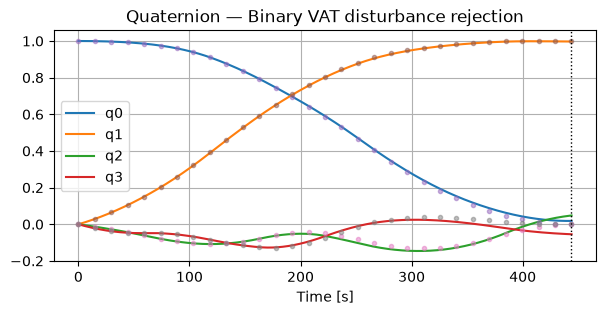

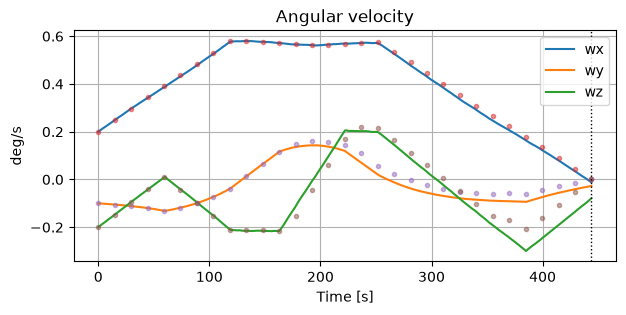

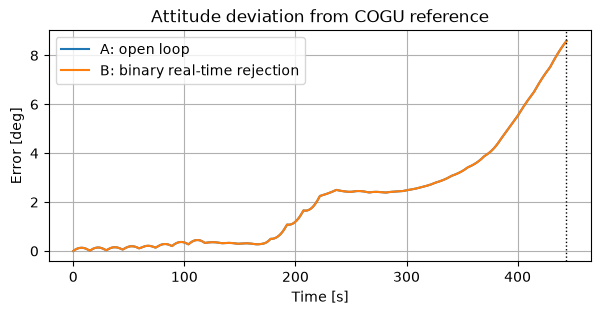

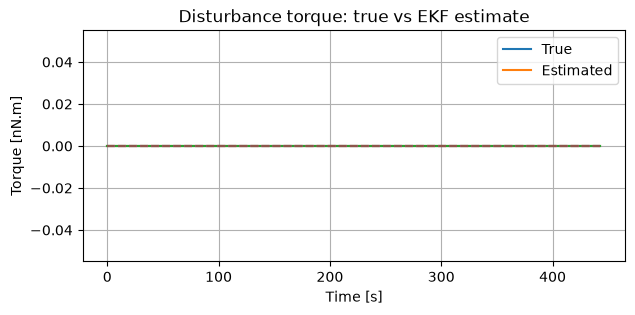

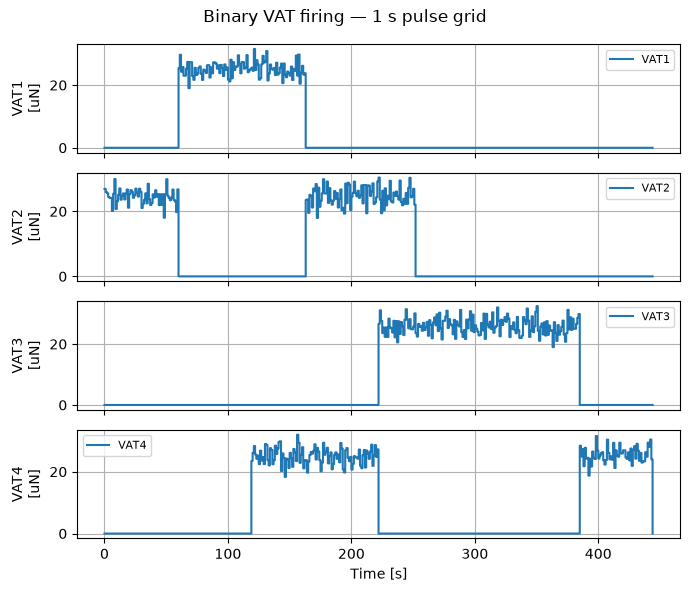

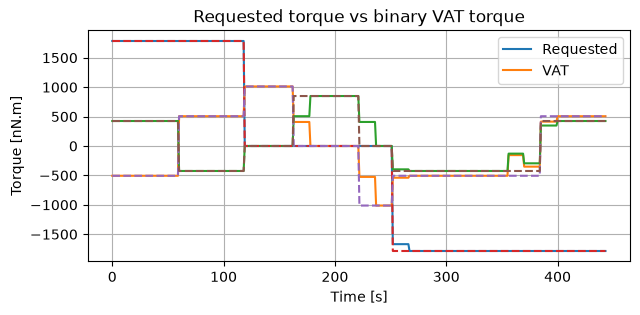

In [172]:
# ============================================================================
# VAT OPEN-LOOP COGU + REAL-TIME DISTURBANCE-TORQUE REJECTION
# BINARY THRESHOLD CONTROL — NO PWM / NO SIGMA-DELTA / NO LOOKAHEAD
# ----------------------------------------------------------------------------
# At every 1 s slot:
#
#   1. Read current disturbance estimate from EKF:
#          tau_hat_d(t_k)
#
#   2. Compute required torque:
#          tau_req = B*u_COGU - tau_hat_d
#
#   3. Select binary ON/OFF VAT commands using a threshold.
#
#      Each VAT is either:
#          0 N
#          Fth_max
#
#      during the entire 1 s slot.
#
#   4. Only one VAT of each antagonistic pair can fire:
#
#          VAT1 XOR VAT2
#          VAT3 XOR VAT4
#
# No future disturbance information is used.
#
# The disturbance rejection is therefore genuinely REAL-TIME and CAUSAL.
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================================
# 1. VAT CONTROL MATRIX
# ============================================================================

B = np.column_stack([
    np.cross(rth1_double[:, 0], fth1_double[:, 0]),
    np.cross(rth2_double[:, 0], fth2_double[:, 0]),
    np.cross(rth3_double[:, 0], fth3_double[:, 0]),
    np.cross(rth4_double[:, 0], fth4_double[:, 0]),
])

I_nominal = Jsat_double.copy()

print("\n============================================================")
print("VAT BINARY THRESHOLD DISTURBANCE REJECTION")
print("============================================================")


# ============================================================================
# 2. GUIDANCE HORIZON
# ============================================================================

tf_sim = float(tf)
dt_control = tf_sim / T

print(f"Time dilation solution : tf = {tf_sim:.2f} s")
print(f"COGU guidance step     : dt = {dt_control:.3f} s")


# ============================================================================
# 3. VAT ACTUATION
# ============================================================================

dt_pulse = 1.0                       # VAT actuation period [s]
thrust_nominal = Fth_max_double      # maximum VAT thrust [N]

# One complete pulse during the entire 1 s slot
pulse_width = 1.0

q_bit = thrust_nominal * pulse_width * dt_pulse


print("\nVAT actuator:")
print(f"  dt_pulse       = {dt_pulse:.2f} s")
print(f"  Fth_max        = {thrust_nominal*1e6:.3f} uN")
print(f"  pulse width    = {pulse_width:.2f}")
print(f"  impulse        = {q_bit*1e6:.3f} uN.s")


# ============================================================================
# 4. BINARY ACTUATION SET
# ============================================================================
#
# Allowed combinations:
#
#       Pair 1: {OFF, VAT1, VAT2}
#       Pair 2: {OFF, VAT3, VAT4}
#
# Therefore:
#
#       3 x 3 = 9 possible binary states
#
# No PWM.
# No fractional thrust.
# No simultaneous firing inside an antagonistic pair.
# ============================================================================

U_OPT = []

for a in (None, 0, 1):
    for b in (None, 2, 3):

        u = np.zeros(4)

        if a is not None:
            u[a] = thrust_nominal

        if b is not None:
            u[b] = thrust_nominal

        U_OPT.append(u)

U_OPT = np.array(U_OPT)

# Torque generated by each binary state
TAU_OPT = B @ U_OPT.T

# Momentum generated during one complete slot
DH_OPT = TAU_OPT * dt_pulse

NFIRE = (U_OPT > 0).sum(axis=1)


print("\nBinary actuation states:")
print(U_OPT / thrust_nominal)

print("\nTorque authority per VAT [uN.m]:")
print(
    np.round(
        np.linalg.norm(B, axis=0)
        * thrust_nominal
        * 1e6,
        3
    )
)

print("\nMomentum per complete pulse [uN.m.s]:")
print(
    np.round(
        np.linalg.norm(B, axis=0)
        * q_bit
        * 1e6,
        4
    )
)


# ============================================================================
# 5. DISTURBANCE MODEL
# ============================================================================

pert_seed = 0
rng = np.random.default_rng(pert_seed)

# ---------------------------------------------------------------------------
# TRUE disturbance torque
# ---------------------------------------------------------------------------

def disturbance_torque(t):

    return 0 * np.array([
        0.2e-7 * np.sin(2*np.pi*t/5400),
        0.0e-7 * np.sin(2*np.pi*t/4200 + 1.3),
        0.3e-7 * np.sin(2*np.pi*t/6800 + 2.1)
    ])


# ============================================================================
# 6. ONLINE DISTURBANCE ESTIMATE
# ============================================================================
#
# This is the EKF interface.
#
# IMPORTANT:
#
# At time t_k:
#
#       tau_hat = disturbance_estimate(t_k)
#
# Nothing about t > t_k is used.
# ============================================================================

est_scale = 1.0
est_bias = np.zeros(3)

est_sigma = 0.0

_est_rng = np.random.default_rng(pert_seed + 7)


def disturbance_estimate(t):

    tau = (
        est_scale * disturbance_torque(t)
        + est_bias
    )

    if est_sigma > 0:

        tau += (
            est_sigma
            * _est_rng.standard_normal(3)
        )

    return tau


# ============================================================================
# 7. COGU GUIDANCE
# ============================================================================
#
# The COGU solution is known offline.
#
# u_value[:,k]
#
# contains the nominal thrust command for guidance interval k.
# ============================================================================

def u_guid_zoh(t):

    k = int(np.floor(t / dt_control))

    if k < 0 or k >= u_value.shape[1]:

        return np.zeros(4)

    return u_value[:, k]


# ============================================================================
# 8. BINARY THRESHOLD PARAMETERS
# ============================================================================

# Threshold relative to the available torque of the selected VAT.
#
# Example:
#
# threshold_ratio = 0.50
#
# means that if the requested torque component is more than 50% of the
# corresponding VAT authority, that VAT is fired.
#
# The exact value should be tuned using simulation.
# ============================================================================

threshold_ratio = 0.50


# ============================================================================
# 9. BINARY VAT SCHEDULER
# ============================================================================

class BinaryVATScheduler:

    """
    Real-time binary VAT controller.

    At every 1 s slot:

        tau_hat_d = current disturbance estimate

        tau_req = tau_COGU - tau_hat_d

    The controller then selects:

        OFF / VAT1 / VAT2

    and

        OFF / VAT3 / VAT4

    using a simple threshold.

    No PWM.
    No Sigma-Delta.
    No future disturbance.
    """

    def __init__(self, M, reject_disturbance=True):

        self.M = M
        self.reject = reject_disturbance

        self.tau_hat_hist = np.zeros((M, 3))
        self.tau_req_hist = np.zeros((M, 3))
        self.tau_vat_hist = np.zeros((M, 3))

        self.plan = np.zeros((M, 4))

    # ------------------------------------------------------------------------
    # Binary decision
    # ------------------------------------------------------------------------

    def select_binary(self, tau_req):

        # ================================================================
        # OPTION 1: evaluate all 9 binary states
        #
        # This is still a simple threshold/nearest-state controller.
        #
        # We choose the binary state whose generated torque is closest
        # to the requested torque.
        # ================================================================

        torque_error = TAU_OPT.T - tau_req

        cost = np.sum(torque_error**2, axis=1)

        j = np.argmin(cost)

        return U_OPT[j]

    # ------------------------------------------------------------------------
    # Real-time step
    # ------------------------------------------------------------------------

    def step(self, k, tau_hat):

        # ------------------------------------------------------------
        # COGU command available from offline guidance
        # ------------------------------------------------------------

        t = k * dt_pulse

        u_cogu = u_guid_zoh(t)

        tau_cogu = B @ u_cogu


        # ------------------------------------------------------------
        # Disturbance rejection
        # ------------------------------------------------------------

        if self.reject:

            tau_req = tau_cogu - tau_hat

        else:

            tau_req = tau_cogu


        # ------------------------------------------------------------
        # Binary VAT selection
        # ------------------------------------------------------------

        u_cmd = self.select_binary(tau_req)


        # ------------------------------------------------------------
        # Store diagnostics
        # ------------------------------------------------------------

        self.tau_hat_hist[k] = tau_hat
        self.tau_req_hist[k] = tau_req
        self.tau_vat_hist[k] = B @ u_cmd

        self.plan[k] = u_cmd


        return u_cmd


# ============================================================================
# 10. THRUSTER UNCERTAINTIES
# ============================================================================

thrust_offset = 0.0

thrust_sigma = Fth_max_double / 10

thrust_bias_sigma = Fth_max_double / 20

thrust_bias = (
    thrust_bias_sigma
    * rng.standard_normal(4)
)


# ============================================================================
# 11. INERTIA UNCERTAINTY
# ============================================================================

inertia_var = 0.0

while True:

    P = (
        1.0
        + inertia_var
        * (2.0*rng.random((3,3)) - 1.0)
    )

    P = 0.5 * (P + P.T)

    I_true = I_nominal * P

    if np.all(np.linalg.eigvalsh(I_true) > 0):

        break


print("\nInertia:")
print("Nominal:")
print(np.diag(I_nominal))

print("True:")
print(np.diag(I_true))


# ============================================================================
# 12. TRUE DYNAMICS
# ============================================================================

params = {
    "I": I_true,
    "I_inv": np.linalg.inv(I_true),
    "B": B,
    "use_thrusters": True
}


def dynamics(t, x, u, params):

    q = x[0:4]
    w = x[4:7]

    I = params["I"]
    I_inv = params["I_inv"]

    # VAT torque
    tau_vat = (
        params["B"] @ u
        if params["use_thrusters"]
        else np.zeros(3)
    )

    # TRUE disturbance
    tau_d = disturbance_torque(t)

    # Euler equation
    w_dot = I_inv @ (
        tau_vat
        + tau_d
        - np.cross(w, I @ w)
    )

    wx, wy, wz = w

    q0, q1, q2, q3 = q

    q_dot = 0.5 * np.array([

        -wx*q1 - wy*q2 - wz*q3,

         wx*q0 + wz*q2 - wy*q3,

         wy*q0 - wz*q1 + wx*q3,

         wz*q0 + wy*q1 - wx*q2

    ])

    return np.concatenate(
        (q_dot, w_dot)
    )


# ============================================================================
# 13. RK4
# ============================================================================

def rk4_step(f, t, x, u, dt, params):

    k1 = f(
        t,
        x,
        u,
        params
    )

    k2 = f(
        t + dt/2,
        x + dt*k1/2,
        u,
        params
    )

    k3 = f(
        t + dt/2,
        x + dt*k2/2,
        u,
        params
    )

    k4 = f(
        t + dt,
        x + dt*k3,
        u,
        params
    )

    return x + (
        dt/6
        * (k1 + 2*k2 + 2*k3 + k4)
    )


# ============================================================================
# 14. REFERENCE QUATERNION
# ============================================================================

def q_ref_at(t):

    idx = min(
        int(np.floor(t / dt_control)),
        T - 1
    )

    a = min(
        max(
            (t - idx*dt_control)
            / dt_control,
            0.0
        ),
        1.0
    )

    q0 = x_value[0:4, idx]
    q1 = x_value[0:4, idx+1]

    if np.dot(q0, q1) < 0:

        q1 = -q1

    qr = (
        (1-a)*q0
        + a*q1
    )

    return qr / np.linalg.norm(qr)


# ============================================================================
# 15. SIMULATION
# ============================================================================

dt_state_target = 0.1

steps_per_slot = max(
    1,
    int(np.ceil(
        dt_pulse / dt_state_target
    ))
)

dt_state = (
    dt_pulse
    / steps_per_slot
)


def run(
    reject_disturbance,
    noise_seed
):

    M = int(
        round(
            tf_sim / dt_pulse
        )
    )

    scheduler = BinaryVATScheduler(
        M,
        reject_disturbance
    )

    nrng = np.random.default_rng(
        noise_seed
    )

    noise = nrng.standard_normal(
        (M, 4)
    )


    # ------------------------------------------------------------------------
    # Storage
    # ------------------------------------------------------------------------

    N_steps = (
        M
        * steps_per_slot
        + 1
    )

    q_h = np.zeros(
        (N_steps, 4)
    )

    w_h = np.zeros(
        (N_steps, 3)
    )

    u_h = np.zeros(
        (N_steps, 4)
    )

    uc_h = np.zeros(
        (N_steps, 4)
    )

    e_h = np.zeros(
        N_steps
    )

    t_h = np.zeros(
        N_steps
    )


    # ------------------------------------------------------------------------
    # Initial state
    # ------------------------------------------------------------------------

    x = x_value[:, 0].copy()

    x[0:4] /= np.linalg.norm(
        x[0:4]
    )

    t = 0.0

    i = 0


    # ------------------------------------------------------------------------
    # REAL-TIME LOOP
    # ------------------------------------------------------------------------

    for k in range(M):

        # ================================================================
        # 1. CURRENT EKF ESTIMATE
        #
        # This is the only disturbance information available.
        # ================================================================

        tau_hat = disturbance_estimate(t)


        # ================================================================
        # 2. BINARY DECISION
        #
        # Decision is made NOW.
        # ================================================================

        u_cmd = scheduler.step(
            k,
            tau_hat
        )


        # ================================================================
        # 3. THRUSTER UNCERTAINTY
        # ================================================================

        fired = (
            u_cmd > 0
        )

        u_real = np.where(

            fired,

            np.clip(
                u_cmd
                + thrust_offset
                + thrust_bias
                + thrust_sigma*noise[k],

                0.0,
                None
            ),

            0.0
        )


        # ================================================================
        # 4. PROPAGATE DURING THE 1 s SLOT
        # ================================================================

        for s in range(
            steps_per_slot
        ):

            # Binary:
            #
            # ON for entire slot
            # OFF for entire slot

            uu = u_real

            uu_c = u_cmd


            # Store
            q_h[i] = x[0:4]
            w_h[i] = x[4:7]

            t_h[i] = t

            u_h[i] = uu
            uc_h[i] = uu_c


            # Attitude tracking error

            qr = q_ref_at(
                min(t, tf_sim)
            )

            e_h[i] = (
                2.0
                * np.degrees(
                    np.arccos(
                        np.clip(
                            abs(
                                np.dot(
                                    x[0:4],
                                    qr
                                )
                            ),
                            0,
                            1
                        )
                    )
                )
            )


            # RK4

            x = rk4_step(
                dynamics,
                t,
                x,
                uu,
                dt_state,
                params
            )


            # Normalize quaternion

            x[0:4] /= np.linalg.norm(
                x[0:4]
            )

            t += dt_state

            i += 1


    # Final sample

    q_h[i] = x[0:4]
    w_h[i] = x[4:7]
    t_h[i] = t

    qr = q_ref_at(
        min(t, tf_sim)
    )

    e_h[i] = (
        2.0
        * np.degrees(
            np.arccos(
                np.clip(
                    abs(
                        np.dot(
                            x[0:4],
                            qr
                        )
                    ),
                    0,
                    1
                )
            )
        )
    )


    return {

        "t": t_h,
        "q": q_h,
        "w": w_h,

        "u": u_h,
        "ucmd": uc_h,

        "err": e_h,

        "plan": scheduler.plan,

        "t_slot":
            np.arange(M)
            * dt_pulse,

        "scheduler":
            scheduler
    }


# ============================================================================
# 16. RUN BOTH CASES
# ============================================================================

q_end = (
    x_value[0:4, T]
    / np.linalg.norm(
        x_value[0:4, T]
    )
)


runs = {}


for tag, rejection in (

    ("A: open loop", False),

    ("B: binary real-time rejection", True)

):

    out = run(
        rejection,
        noise_seed=pert_seed + 1
    )


    out["final_pt"] = (

        2.0
        * np.degrees(

            np.arccos(

                np.clip(

                    abs(
                        np.dot(
                            out["q"][-1],
                            q_end
                        )
                    ),

                    0,
                    1
                )
            )
        )
    )


    runs[tag] = out


    plan = out["plan"]


    # Check pair exclusivity

    excl = (

        np.all(
            plan[:,0]
            * plan[:,1]
            == 0
        )

        and

        np.all(
            plan[:,2]
            * plan[:,3]
            == 0
        )
    )


    print("\n------------------------------------------------------------")
    print(tag)
    print("------------------------------------------------------------")

    print(
        "Pair exclusivity:",
        excl
    )

    print(
        "Pulses per VAT:",
        (plan > 0).sum(axis=0)
    )

    print(
        "Total firing events:",
        (plan > 0).sum()
    )

    print(
        "Final tracking error:",
        f"{out['err'][-1]:.6f} deg"
    )

    print(
        "Maximum tracking error:",
        f"{out['err'].max():.6f} deg"
    )

    print(
        "Final pointing error:",
        f"{out['final_pt']:.6f} deg"
    )


# ============================================================================
# 17. IMPROVEMENT
# ============================================================================

impA = runs[
    "A: open loop"
]["final_pt"]

impB = runs[
    "B: binary real-time rejection"
]["final_pt"]


print("\n============================================================")
print("DISTURBANCE REJECTION PERFORMANCE")
print("============================================================")

print(
    f"Open loop          : {impA:.6f} deg"
)

print(
    f"Binary rejection   : {impB:.6f} deg"
)

print(
    f"Improvement        : "
    f"{100*(impA-impB)/max(impA,1e-12):.2f} %"
)


# ============================================================================
# 18. PLOTS
# ============================================================================

t_nodes = (
    np.arange(T + 1)
    * dt_control
)


ref = runs[
    "B: binary real-time rejection"
]


# ============================================================================
# Quaternion
# ============================================================================

plt.figure(
    figsize=(7,3)
)

plt.plot(
    ref["t"],
    ref["q"]
)

plt.plot(
    t_nodes,
    x_value[0:4,:].T,
    'o',
    ms=3,
    alpha=0.5
)

plt.axvline(
    tf_sim,
    color='k',
    ls=':',
    lw=1
)

plt.legend([
    "q0",
    "q1",
    "q2",
    "q3"
])

plt.title(
    "Quaternion — Binary VAT disturbance rejection"
)

plt.xlabel(
    "Time [s]"
)

plt.grid()

plt.show()


# ============================================================================
# Angular velocity
# ============================================================================

plt.figure(
    figsize=(7,3)
)

plt.plot(
    ref["t"],
    ref["w"] * 180/np.pi
)

plt.plot(
    t_nodes,
    x_value[4:7,:].T
    * 180/np.pi,
    'o',
    ms=3,
    alpha=0.5
)

plt.axvline(
    tf_sim,
    color='k',
    ls=':',
    lw=1
)

plt.legend([
    "wx",
    "wy",
    "wz"
])

plt.title(
    "Angular velocity"
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "deg/s"
)

plt.grid()

plt.show()


# ============================================================================
# Tracking error
# ============================================================================

plt.figure(
    figsize=(7,3)
)

for tag, out in runs.items():

    plt.plot(
        out["t"],
        out["err"],
        label=tag
    )

plt.axvline(
    tf_sim,
    color='k',
    ls=':',
    lw=1
)

plt.title(
    "Attitude deviation from COGU reference"
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "Error [deg]"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================================
# TRUE DISTURBANCE VS ESTIMATE
# ============================================================================

tt = ref["t_slot"]

tau_true = np.array([
    disturbance_torque(t)
    for t in tt
])


tau_hat = (
    ref["scheduler"]
    .tau_hat_hist
)


plt.figure(
    figsize=(7,3)
)

plt.plot(
    tt,
    tau_true * 1e9
)

plt.plot(
    tt,
    tau_hat * 1e9,
    '--'
)

plt.title(
    "Disturbance torque: true vs EKF estimate"
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "Torque [nN.m]"
)

plt.legend([
    "True",
    "Estimated"
])

plt.grid()

plt.show()


# ============================================================================
# VAT COMMANDS
# ============================================================================

fig, axs = plt.subplots(
    4,
    1,
    sharex=True,
    figsize=(7,6)
)


for i in range(4):

    # Binary command

    axs[i].step(
        ref["t"],
        ref["u"][:,i] * 1e6,
        where='post',
        label=f"VAT{i+1}"
    )

    axs[i].set_ylabel(
        f"VAT{i+1}\n[uN]"
    )

    axs[i].grid(
        True
    )

    axs[i].legend(
        fontsize=8
    )


axs[-1].set_xlabel(
    "Time [s]"
)


fig.suptitle(
    "Binary VAT firing — 1 s pulse grid"
)

fig.tight_layout()

plt.show()


# ============================================================================
# REQUESTED TORQUE VS ACTUAL VAT TORQUE
# ============================================================================

tau_req = (
    ref["scheduler"]
    .tau_req_hist
)

tau_vat = (
    ref["scheduler"]
    .tau_vat_hist
)


plt.figure(
    figsize=(7,3)
)

plt.plot(
    tt,
    tau_req * 1e9
)

plt.plot(
    tt,
    tau_vat * 1e9,
    '--'
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "Torque [nN.m]"
)

plt.title(
    "Requested torque vs binary VAT torque"
)

plt.legend([
    "Requested",
    "VAT"
])

plt.grid()

plt.show()